# Notebook 03 — Semantic Analysis (Figures 5, 6, 7 + Table 1)

Implements **Sections 2.3 and 2.4** of the paper.

| Section | Output | Method |
|---|---|---|
| §2.3.1 Semantic Organization | Fig 5 | PCA projection of reasoning-step / answer-chunk embeddings → KDE contour overlays |
| §2.3.2 Directed Trajectories | Fig 6 | Per-response trajectories through phase centroids (Graph-PRefLexOR) or 4 sequential chunks (baselines) |
| §2.4 Quantifying Semantic Diversity | Fig 7 + Table 1 | Inter-phase / inter-chunk centroid cosine distance, per response |

All embeddings use `google/embeddinggemma-300m` (768-dim sentence vectors). Reasoning analyses are restricted to the 8B and 1.7B model pairs (matched base architectures); final-answer analyses cover all three scales (1.7B / 3B / 8B).

## 1. Setup

In [1]:
import os, json
from pathlib import Path
from itertools import combinations
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

import nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt_tab", quiet=True)

import torch
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

load_dotenv(Path("../.env"))

RESULTS_DIR = Path("../data/results")
CACHE_DIR   = RESULTS_DIR / "embeddings_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Reasoning phases used by Graph-PRefLexOR (graph_json is structural, not embedded
# as a separate semantic region; paper §2.3.1 treats the four content phases).
PHASES = ["brainstorm", "graph", "patterns", "synthesis"]

CMAPS        = {"brainstorm": "Reds", "graph": "Blues", "patterns": "Greens", "synthesis": "Oranges"}
PHASE_COLORS = {"brainstorm": "red",  "graph": "blue",  "patterns": "green",  "synthesis": "orange"}

## 2. Load the embedding model

Auto-selects the best available device. Optional Hugging Face token in `.env` (`HF_TOKEN=...`) for gated models; `embeddinggemma-300m` is public so the token is not required.

In [2]:
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

embedder = SentenceTransformer(
    "google/embeddinggemma-300m",
    token=os.getenv("HF_TOKEN"),   # optional; reads from .env if set
    device=DEVICE,
)
EMB_DIM = embedder.get_sentence_embedding_dimension()
print(f"Embedding model loaded. Output dim: {EMB_DIM}")

def embed_batch(texts: List[str]) -> np.ndarray:
    return embedder.encode(texts, normalize_embeddings=True,
                           show_progress_bar=True, batch_size=128)

Device: mps


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Embedding model loaded. Output dim: 768


/var/folders/5_/b01yl5y57lg29_llv5r56xrh0000gn/T/ipykernel_48300/2719522583.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMB_DIM = embedder.get_sentence_embedding_dimension()


## 3. Load + sentence-tokenize + embed each model

For each model we collect three parallel lists per output type (reasoning trace `_res_` or final answer `_ans_`):
- `texts`  — one entry per sentence
- `labels` — phase name (Graph-PRefLexOR) or model name (baseline)
- `answer_ids` — which question the sentence came from, for per-response analyses

Embeddings are cached on disk (`data/results/embeddings_cache/`) so re-running the notebook only embeds new data.

In [3]:
def _cached_embed(name: str, texts: List[str]) -> np.ndarray:
    """Embed `texts` once and cache to disk; subsequent calls reload from disk."""
    cache = CACHE_DIR / f"{name}.npy"
    if cache.exists():
        emb = np.load(cache)
        if len(emb) == len(texts):
            print(f"  cache hit: {name} ({len(emb)} vectors)")
            return emb
    emb = embed_batch(texts)
    np.save(cache, emb)
    return emb

def split_graph_records(df: pd.DataFrame) -> Tuple[Dict, Dict]:
    """Tokenize a Graph-PRefLexOR eval dataframe.

    Returns ({texts, labels, ids} for the reasoning phases,
             {texts, labels, ids} for the final answer in `llm_output`).
    """
    res = {"texts": [], "labels": [], "ids": []}
    ans = {"texts": [], "labels": [], "ids": []}
    for i, row in df.iterrows():
        rid = str(row.get("id", i))
        for phase in PHASES:
            for s in sent_tokenize(str(row.get(phase, ""))):
                res["texts"].append(s); res["labels"].append(phase); res["ids"].append(rid)
        for s in sent_tokenize(str(row.get("llm_output", ""))):
            ans["texts"].append(s); ans["labels"].append("graph"); ans["ids"].append(rid)
    for d in (res, ans):
        d["ids"] = np.array(d["ids"])
    return res, ans

def split_baseline_records(df: pd.DataFrame, model_label: str,
                            think_col: str = "thinking",
                            answer_col: str = "llm_output") -> Tuple[Dict, Dict]:
    """Tokenize a baseline (Qwen / Llama) eval dataframe. The whole think block
    is treated as a single unstructured region (paper §2.3.1)."""
    res = {"texts": [], "labels": [], "ids": []}
    ans = {"texts": [], "labels": [], "ids": []}
    for i, row in df.iterrows():
        rid = str(row.get("id", i))
        for s in sent_tokenize(str(row.get(think_col, ""))):
            res["texts"].append(s); res["labels"].append(model_label); res["ids"].append(rid)
        for s in sent_tokenize(str(row.get(answer_col, ""))):
            ans["texts"].append(s); ans["labels"].append(model_label); ans["ids"].append(rid)
    for d in (res, ans):
        d["ids"] = np.array(d["ids"])
    return res, ans

In [4]:
# Files were produced by notebook 02 / scripts/eval_*.py
def load_eval(name: str) -> pd.DataFrame:
    return pd.read_json(RESULTS_DIR / f"{name}.jsonl", lines=True)

graph_8b_df   = load_eval("graph_8b_data_eval_all")
graph_3b_df   = load_eval("graph_3b_data_eval_all")
graph_1_7b_df = load_eval("graph_1_7b_data_eval_all")
qwen_8b_df    = load_eval("qwen_8b_data_eval_all")
qwen_1_7b_df  = load_eval("qwen_1_7b_data_eval_all")
llama_3b_df   = load_eval("llama_3b_data_eval_all")

# Graph-PRefLexOR: split by structured phase
g8b_res,   g8b_ans   = split_graph_records(graph_8b_df)
g3b_res,   g3b_ans   = split_graph_records(graph_3b_df)
g1_7b_res, g1_7b_ans = split_graph_records(graph_1_7b_df)

# Baselines: single label per model (Llama has no reasoning trace → only ans)
q8b_res,   q8b_ans   = split_baseline_records(qwen_8b_df,   "qwen")
q1_7b_res, q1_7b_ans = split_baseline_records(qwen_1_7b_df, "qwen")
_,         l3b_ans   = split_baseline_records(llama_3b_df,  "llama",
                                               think_col="__none__",
                                               answer_col="raw_output")

# Embed (cached to disk on first run)
for name, rec in [
    ("graph_8b_res",   g8b_res),   ("graph_8b_ans",   g8b_ans),
    ("graph_3b_ans",   g3b_ans),
    ("graph_1_7b_res", g1_7b_res), ("graph_1_7b_ans", g1_7b_ans),
    ("qwen_8b_res",    q8b_res),   ("qwen_8b_ans",    q8b_ans),
    ("qwen_1_7b_res",  q1_7b_res), ("qwen_1_7b_ans",  q1_7b_ans),
    ("llama_3b_ans",   l3b_ans),
]:
    rec["emb"] = _cached_embed(name, rec["texts"])
    print(f"{name:18s} {len(rec['texts']):5d} sentences → {rec['emb'].shape}")

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

graph_8b_res        2172 sentences → (2172, 768)


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

graph_8b_ans         529 sentences → (529, 768)


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

...

qwen_1_7b_res      12089 sentences → (12089, 768)


Batches:   0%|          | 0/95 [00:00<?, ?it/s]

qwen_1_7b_ans      12089 sentences → (12089, 768)


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

llama_3b_ans        2085 sentences → (2085, 768)


## 4. Figure 5 — Semantic organization (PCA + KDE)

Both models are projected into a *shared* PCA basis so distributions are directly comparable. For Graph-PRefLexOR the four reasoning phases get separate KDEs (each in its own colormap); the baseline is a single grey contour.

In [11]:
def joint_pca(emb_a: np.ndarray, emb_b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Fit PCA on `[emb_a; emb_b]`, return the two halves projected to 2-D."""
    combined = np.vstack([emb_a, emb_b])
    proj = PCA(n_components=2).fit_transform(combined)
    return proj[:len(emb_a)], proj[len(emb_a):]

def _kde_grid(coords_list: List[np.ndarray], pad: float = 0.5, n: int = 200):
    all_xy = np.vstack(coords_list)
    x_min, x_max = all_xy[:,0].min() - pad, all_xy[:,0].max() + pad
    y_min, y_max = all_xy[:,1].min() - pad, all_xy[:,1].max() + pad
    xx, yy = np.mgrid[x_min:x_max:complex(0, n), y_min:y_max:complex(0, n)]
    grid = np.vstack([xx.ravel(), yy.ravel()])
    return xx, yy, grid

def plot_kde_phases(graph_coords: np.ndarray, graph_labels: List[str],
                    base_coords: np.ndarray, title: str,
                    graph_name: str = "Graph-PRefLexOR", base_name: str = "Baseline") -> None:
    """KDE overlay: per-phase contours for Graph-PRefLexOR + single grey contour for baseline."""
    xx, yy, grid = _kde_grid([graph_coords, base_coords])

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    # Baseline as filled grey
    z = gaussian_kde(base_coords.T)(grid).reshape(xx.shape)
    ax.contourf(xx, yy, z, levels=2, cmap="Greys", alpha=0.45)

    # Graph-PRefLexOR per phase
    for phase in PHASES:
        idx = [i for i, l in enumerate(graph_labels) if l == phase]
        if not idx:
            continue
        z = gaussian_kde(graph_coords[idx].T)(grid).reshape(xx.shape)
        levels = np.linspace(z.max() * 0.05, z.max(), 2)
        ax.contour(xx, yy, z, levels=levels, colors=PHASE_COLORS[phase], linewidths=1.2)
        ax.contourf(xx, yy, z, levels=levels, cmap=CMAPS[phase], alpha=0.35)

    handles = [Line2D([0], [0], color="grey", lw=4, alpha=0.5, label=base_name)] + \
              [Line2D([0], [0], color=PHASE_COLORS[p], lw=2, label=f"{graph_name} <{p}>") for p in PHASES]
    ax.legend(handles=handles, fontsize=10, loc="best")
    ax.set_title(title); ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_kde_single(graph_coords: np.ndarray, base_coords: np.ndarray, title: str,
                     graph_name: str = "Graph-PRefLexOR", base_name: str = "Baseline") -> None:
    """KDE overlay for final answers: one contour per model, no phase decomposition."""
    xx, yy, grid = _kde_grid([graph_coords, base_coords])
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    for coords, cmap, color, name in [
        (base_coords,  "Greys", "grey",     base_name),
        (graph_coords, "Reds",  "#E63946",  graph_name),
    ]:
        z = gaussian_kde(coords.T)(grid).reshape(xx.shape)
        levels = np.linspace(z.max() * 0.05, z.max(), 2)
        ax.contour(xx, yy, z, levels=levels, colors=color, linewidths=1.2)
        ax.contourf(xx, yy, z, levels=levels, cmap=cmap, alpha=0.4)
    ax.legend(handles=[Line2D([0],[0], color="grey", lw=4, alpha=0.5, label=base_name),
               Line2D([0],[0], color="#E63946", lw=2, label=graph_name)], fontsize=11)
    ax.set_title(title); ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### Figure 5a — Reasoning traces, 8B

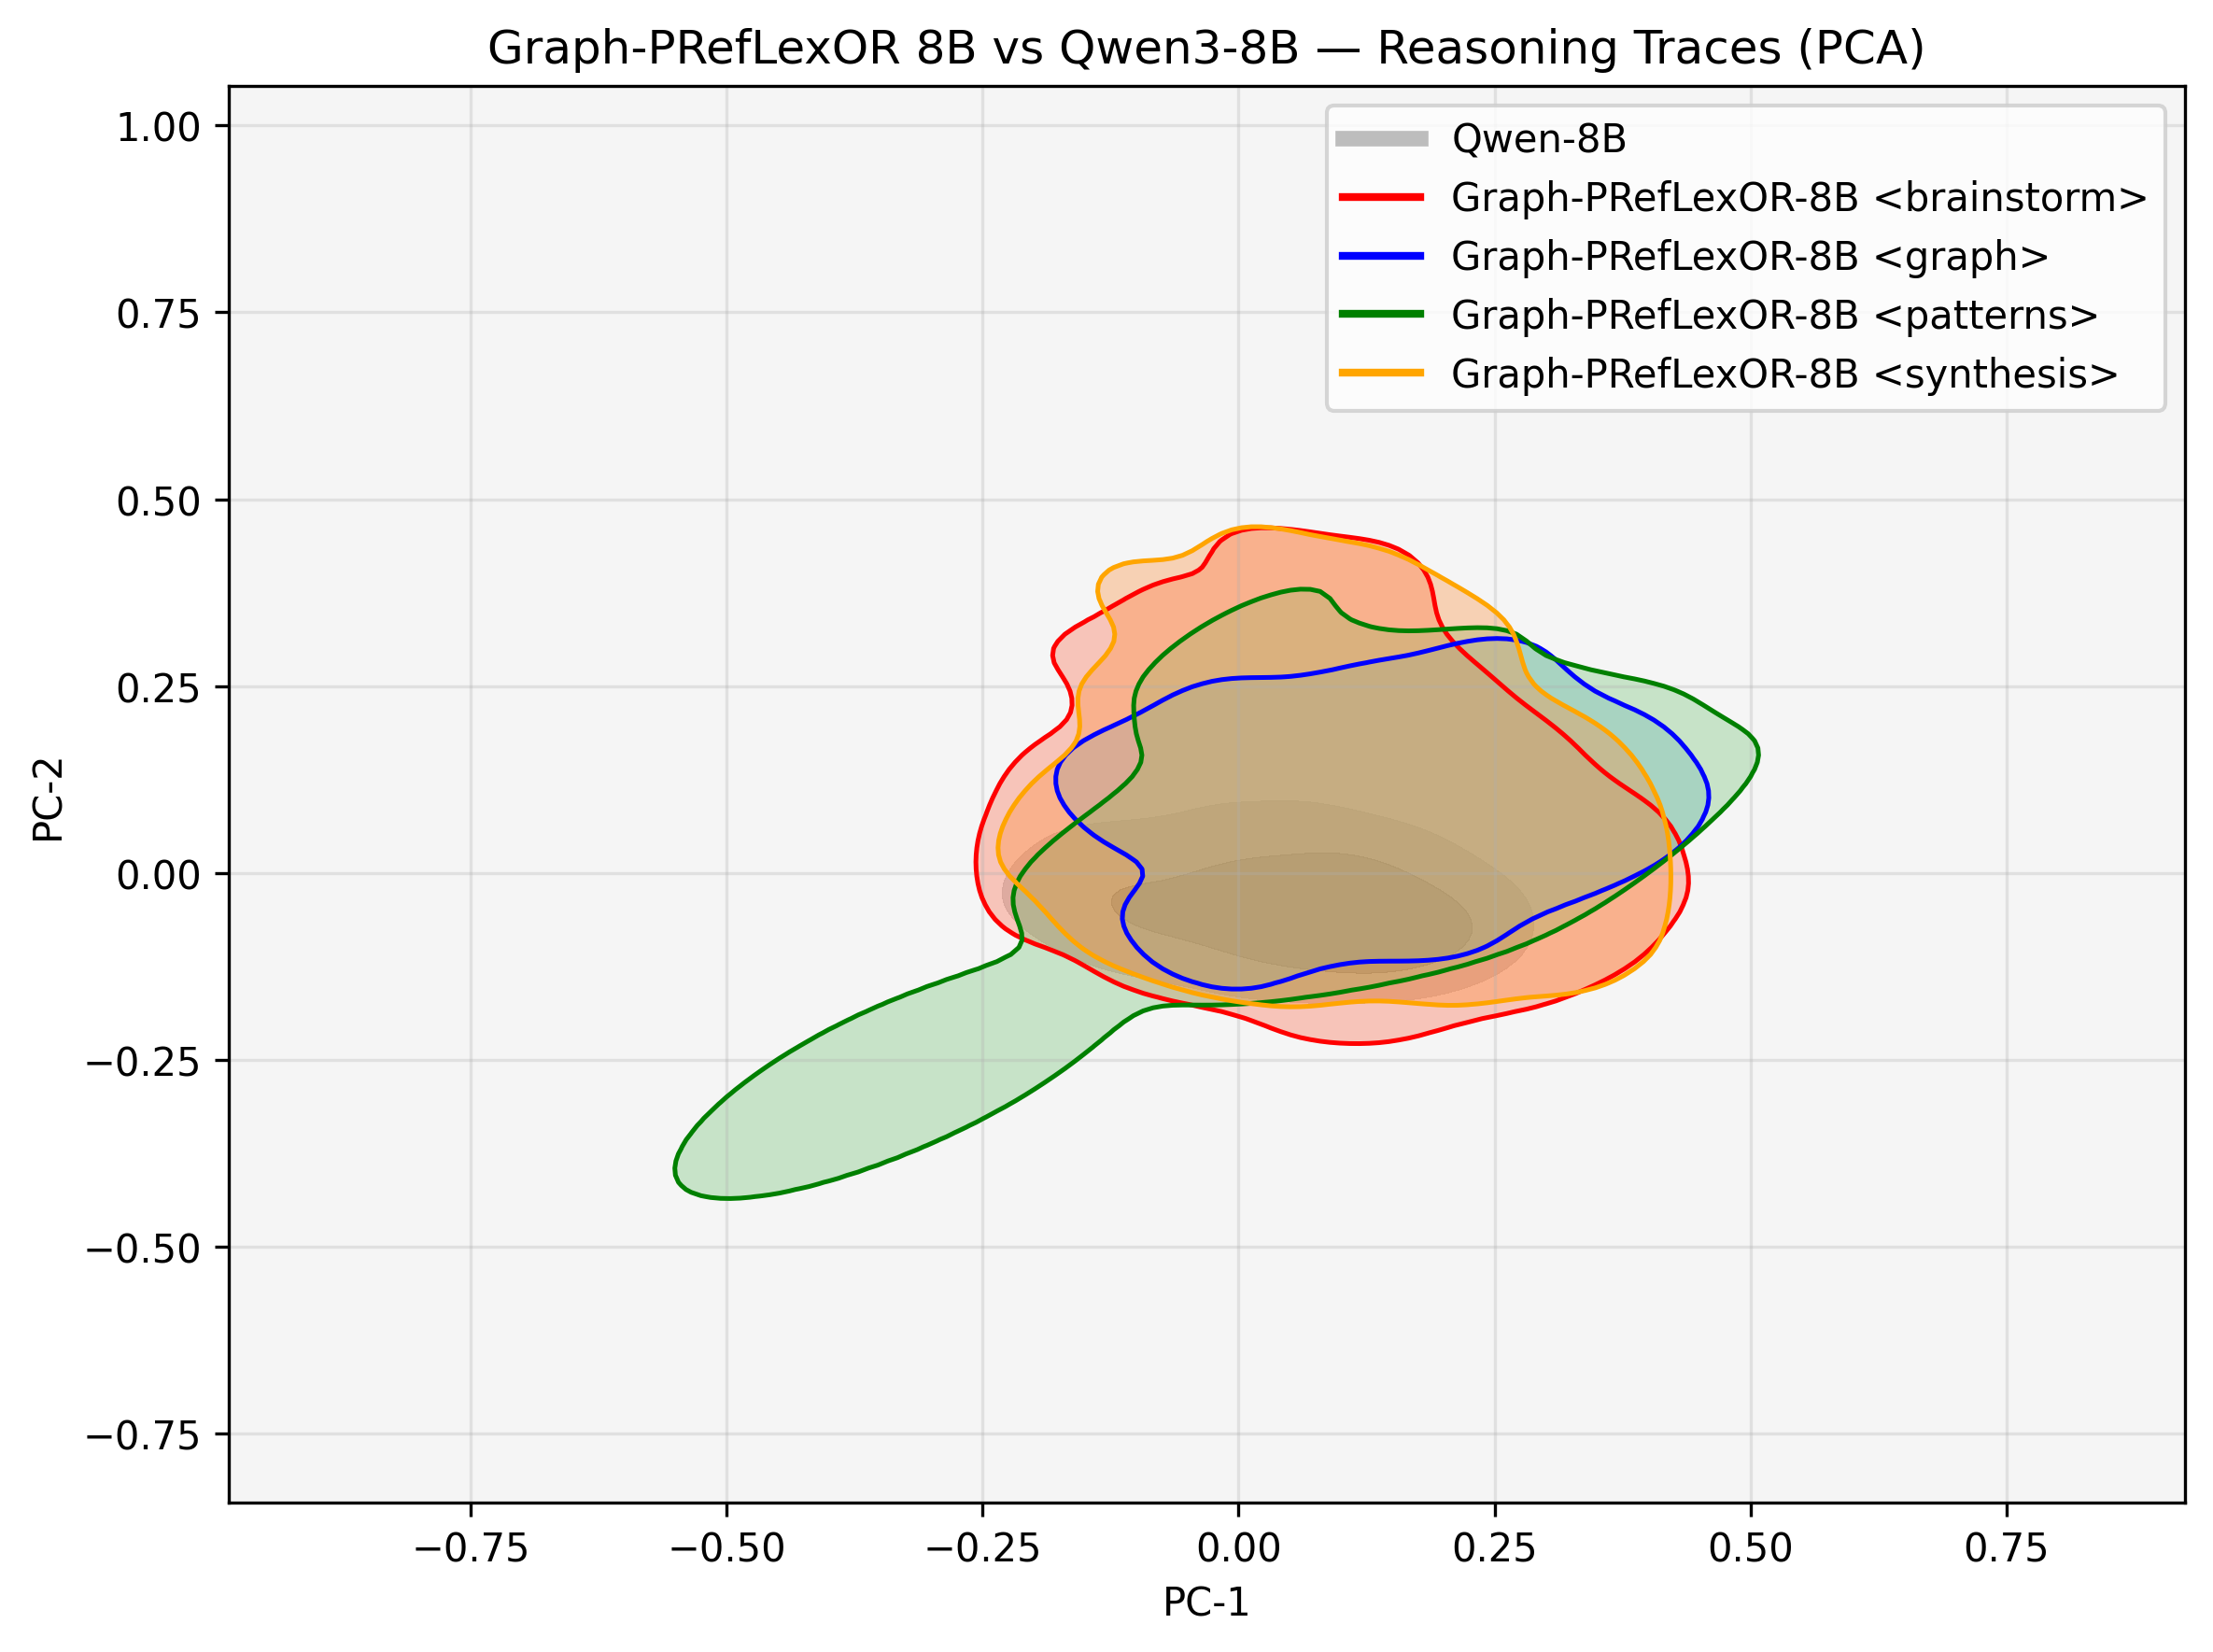

In [12]:
g_pca, q_pca = joint_pca(g8b_res["emb"], q8b_res["emb"])
plot_kde_phases(g_pca, g8b_res["labels"], q_pca,
                "Graph-PRefLexOR 8B vs Qwen3-8B — Reasoning Traces (PCA)",
                graph_name="Graph-PRefLexOR-8B", base_name="Qwen-8B")

### Figure 5b — Reasoning traces, 1.7B

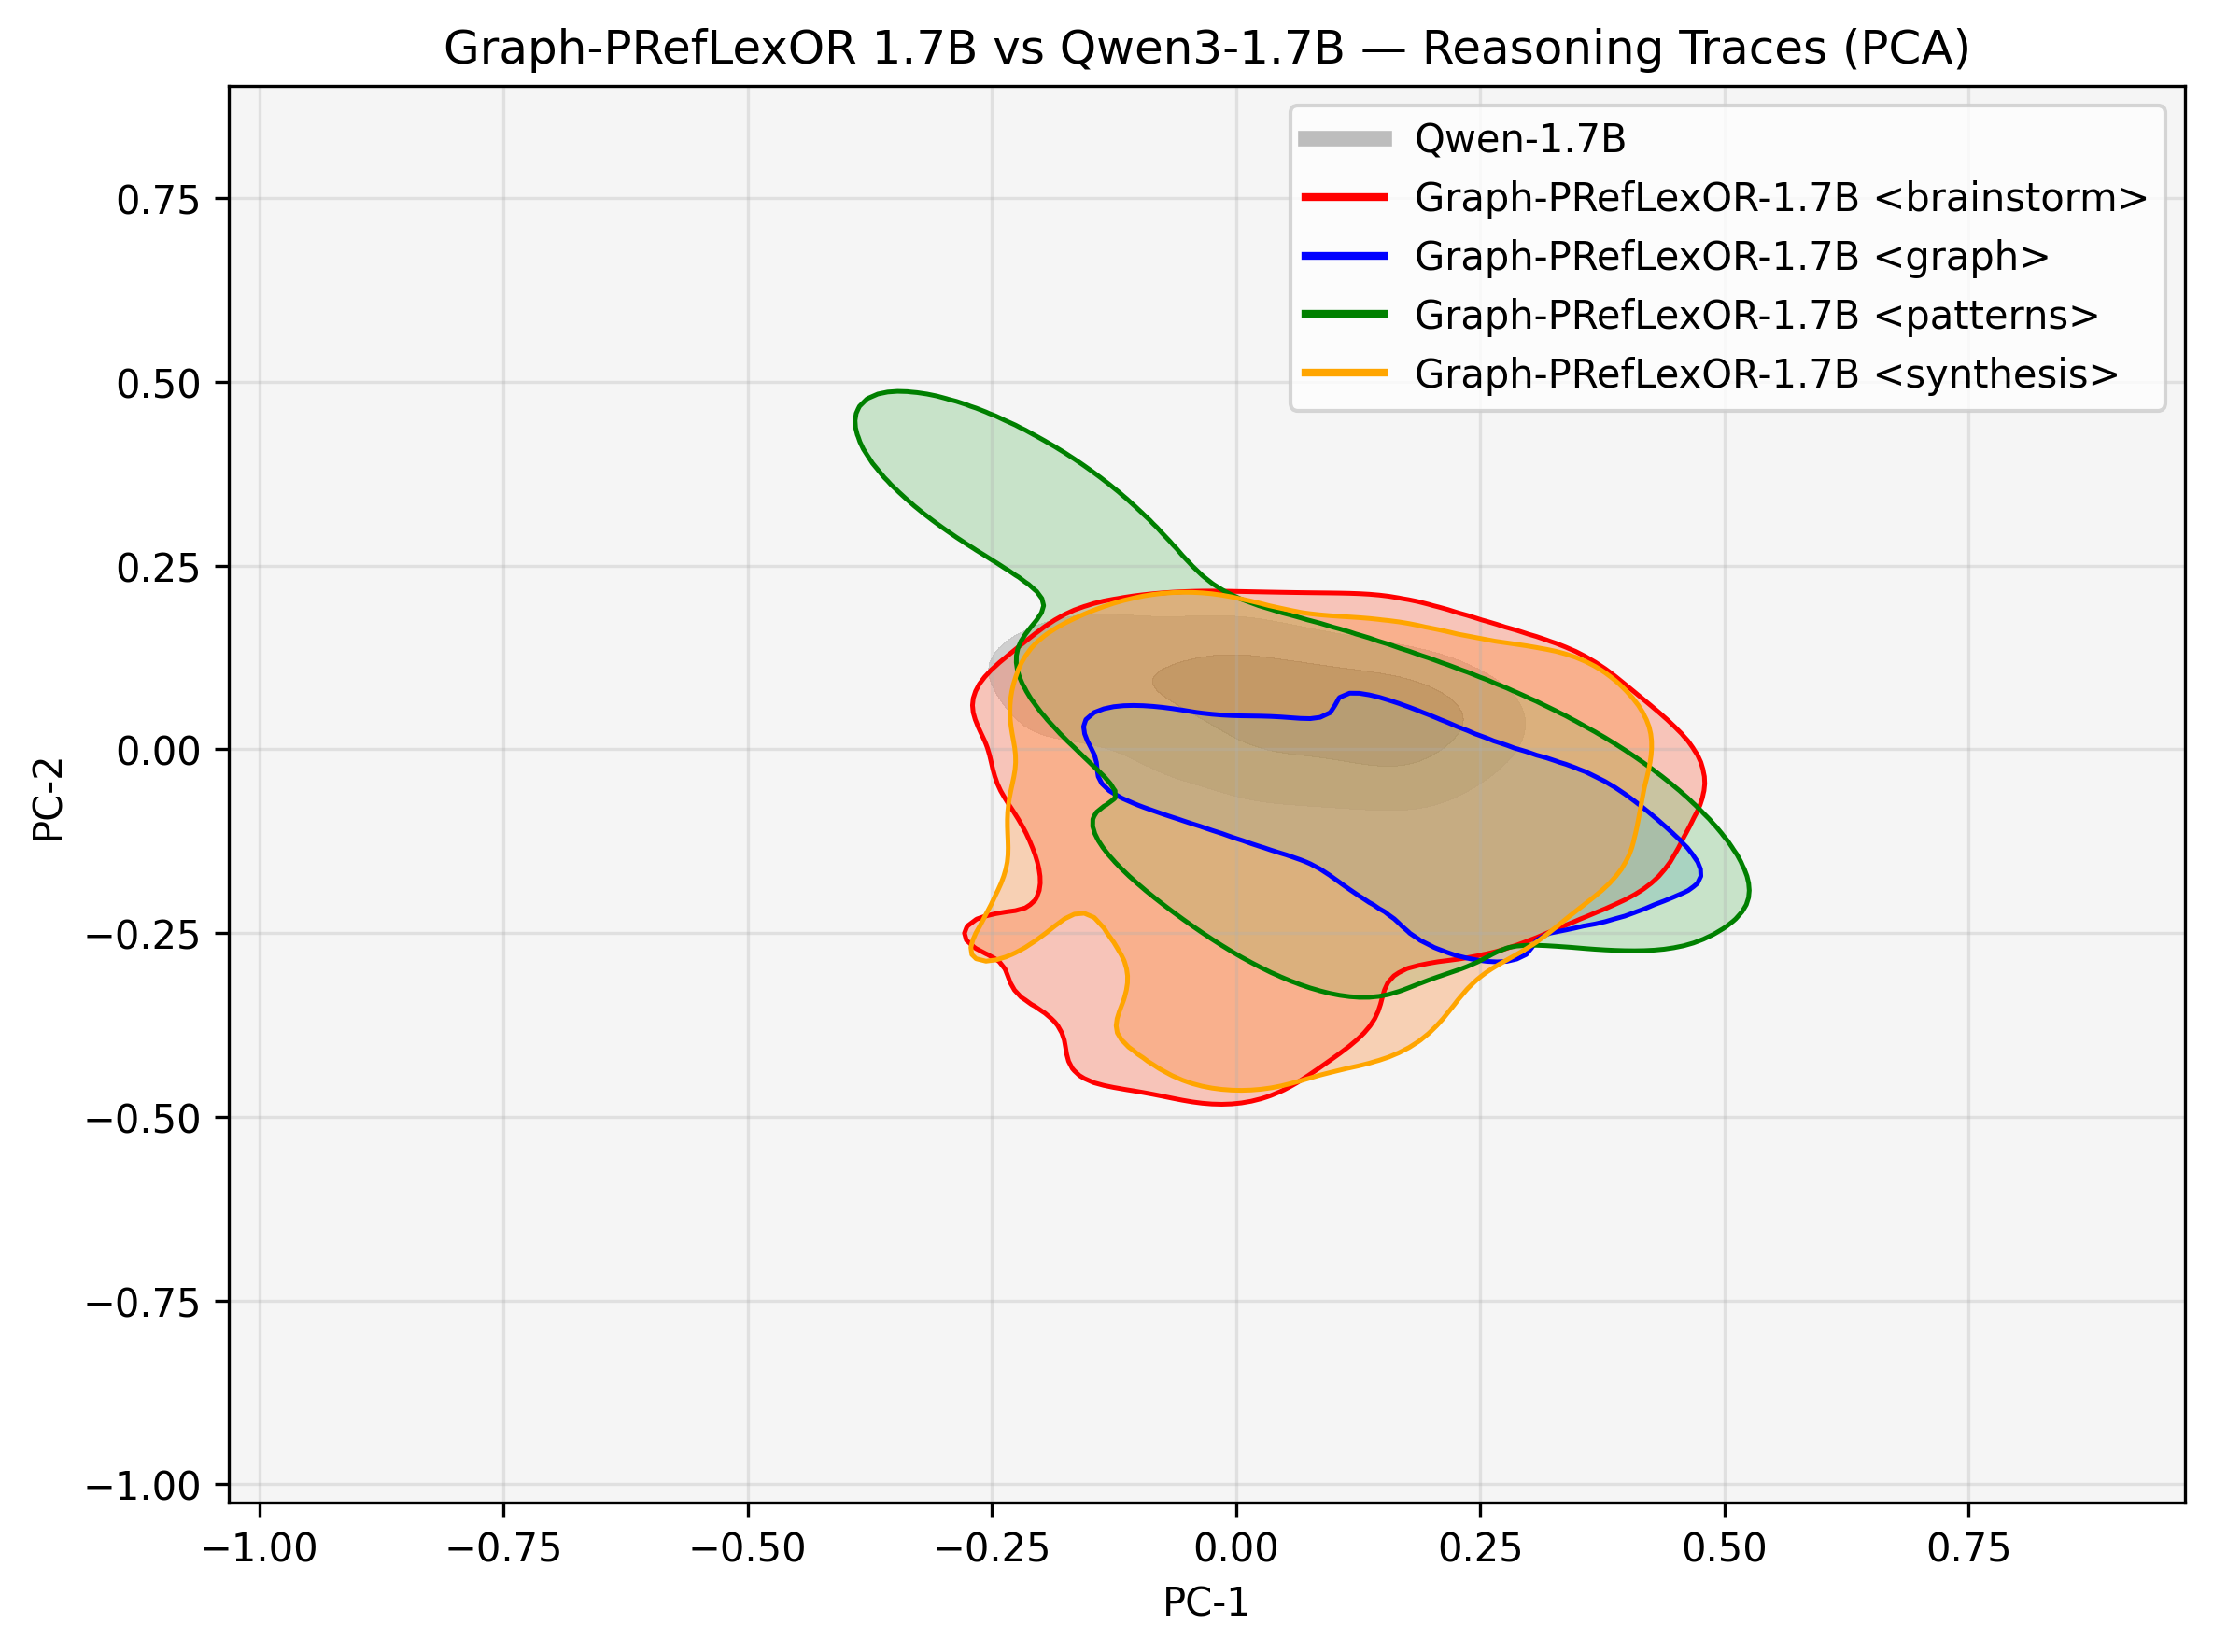

In [13]:
g_pca, q_pca = joint_pca(g1_7b_res["emb"], q1_7b_res["emb"])
plot_kde_phases(g_pca, g1_7b_res["labels"], q_pca,
                "Graph-PRefLexOR 1.7B vs Qwen3-1.7B — Reasoning Traces (PCA)",
                graph_name="Graph-PRefLexOR-1.7B", base_name="Qwen-1.7B")

### Figure 5c — Final answers, 8B

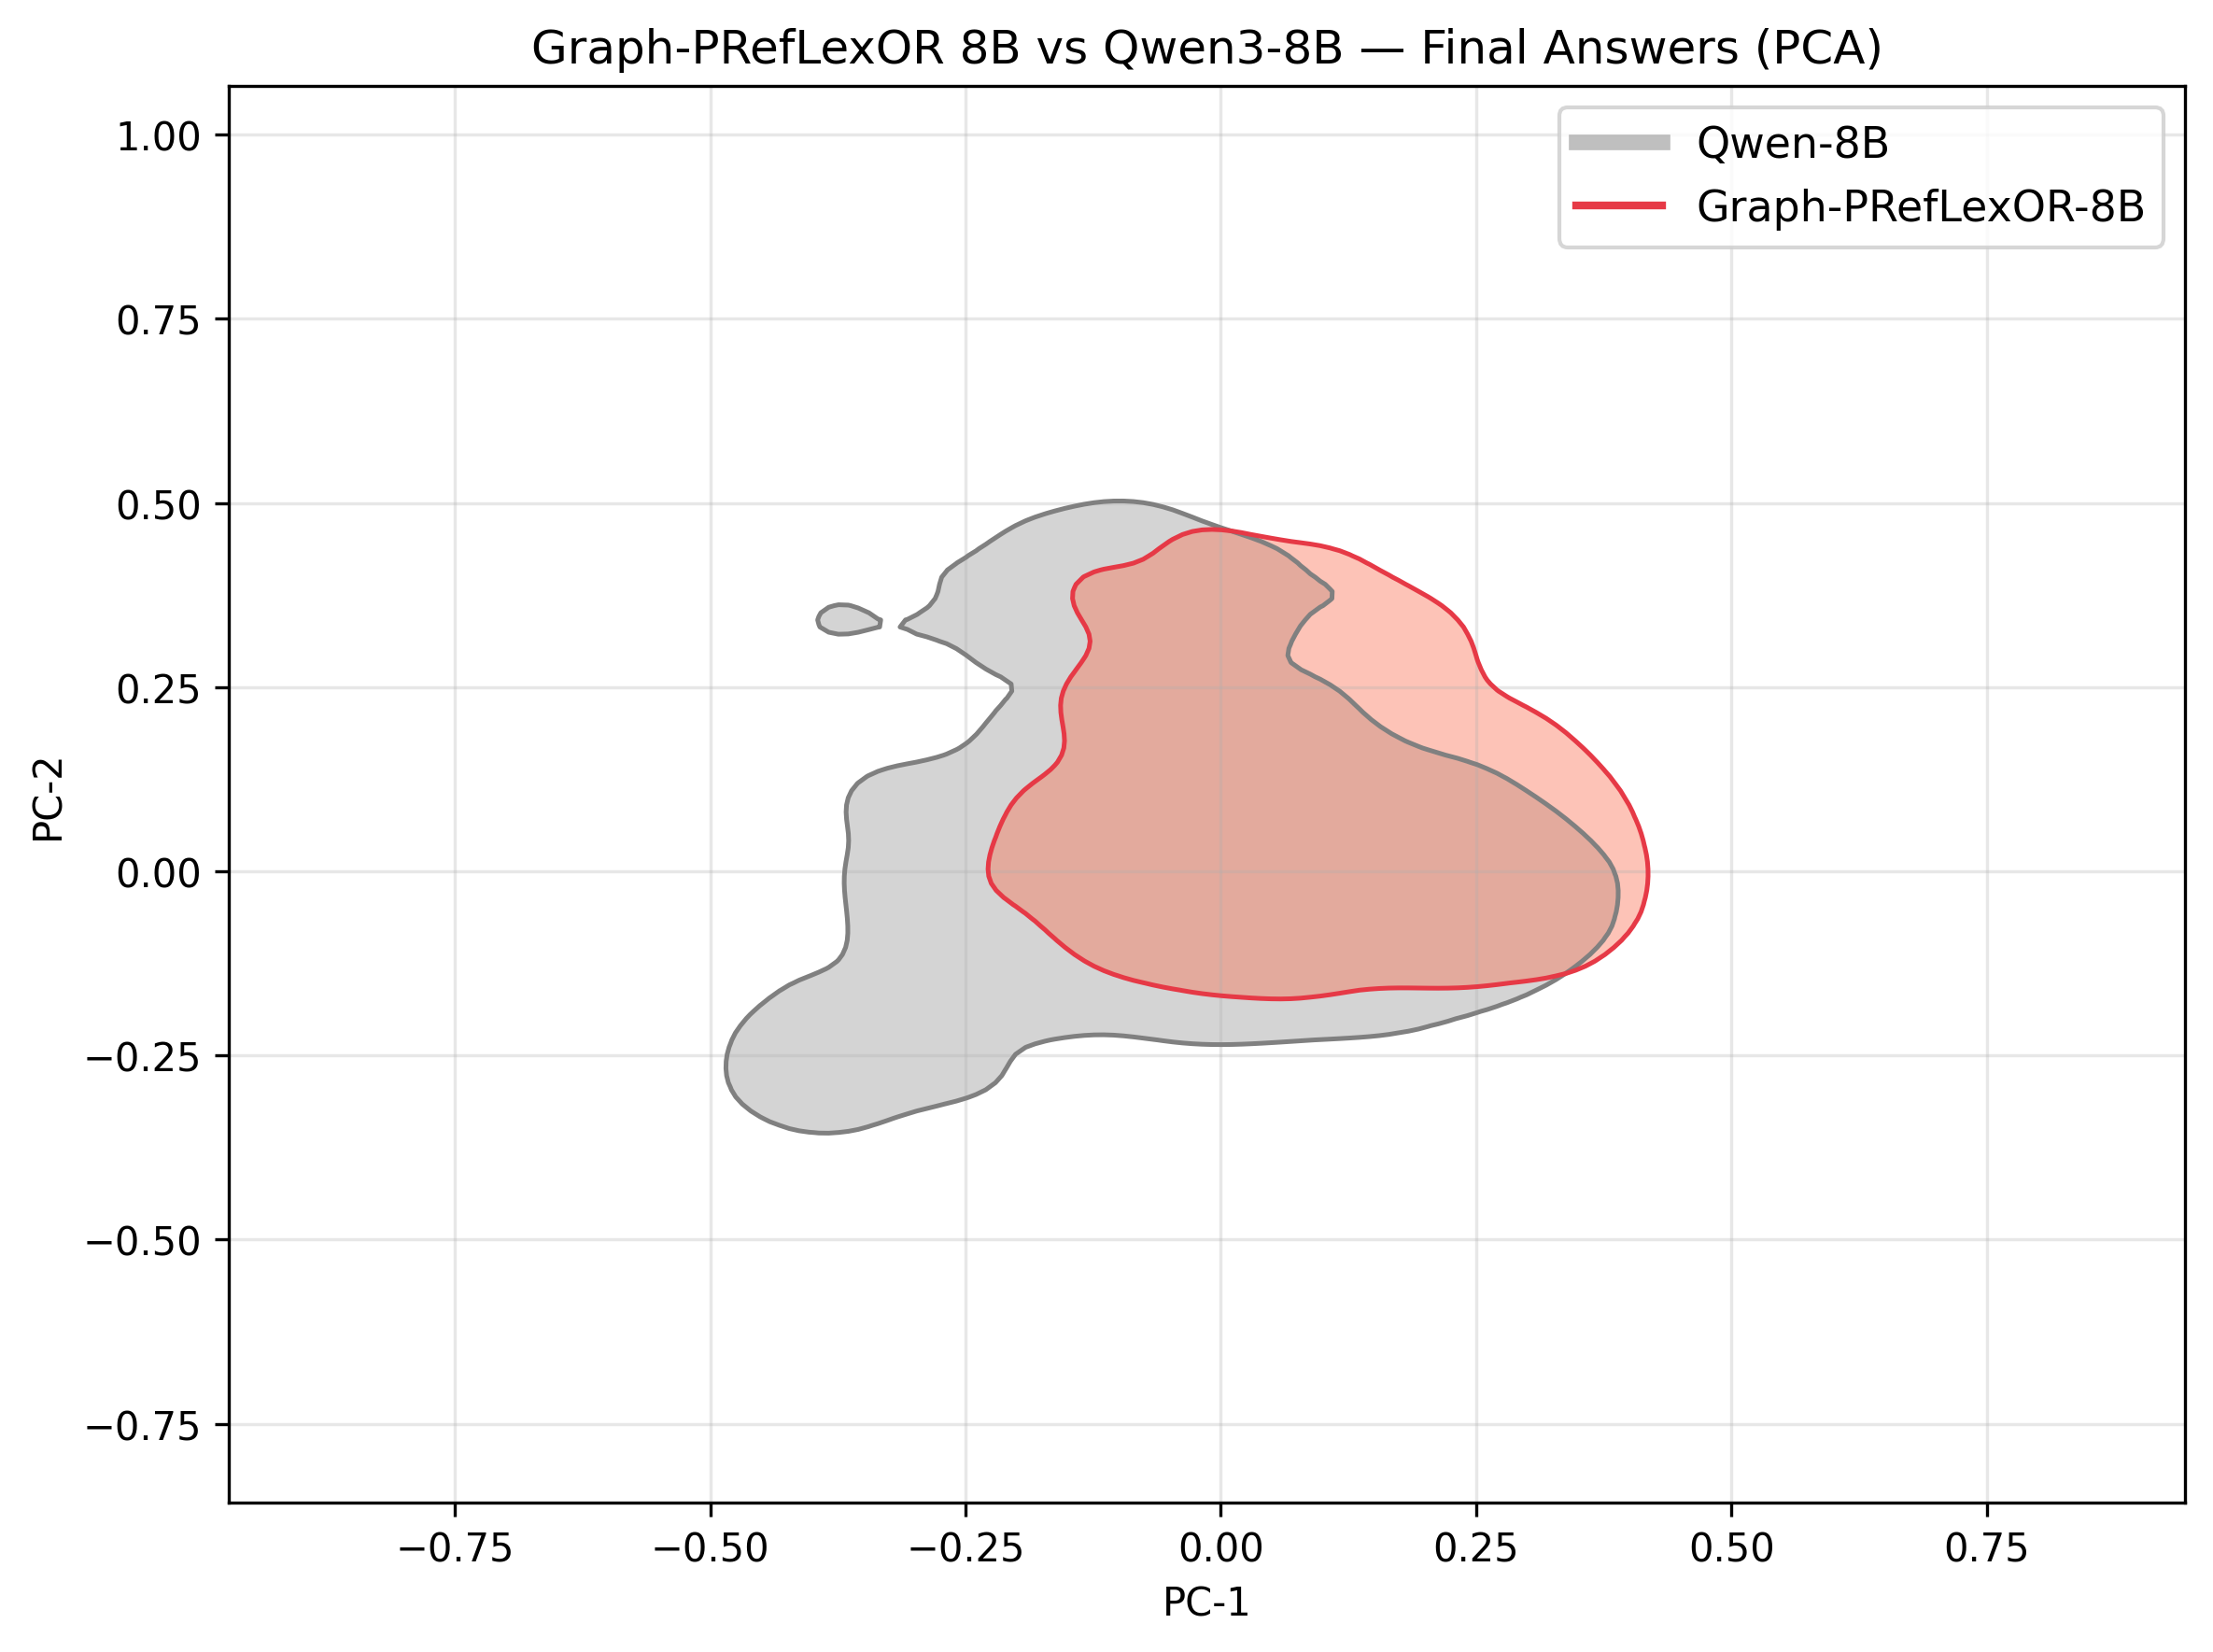

In [14]:
g_pca, q_pca = joint_pca(g8b_ans["emb"], q8b_ans["emb"])
plot_kde_single(g_pca, q_pca,
                "Graph-PRefLexOR 8B vs Qwen3-8B — Final Answers (PCA)",
                graph_name="Graph-PRefLexOR-8B", base_name="Qwen-8B")

### Figure 5d — Final answers, 3B

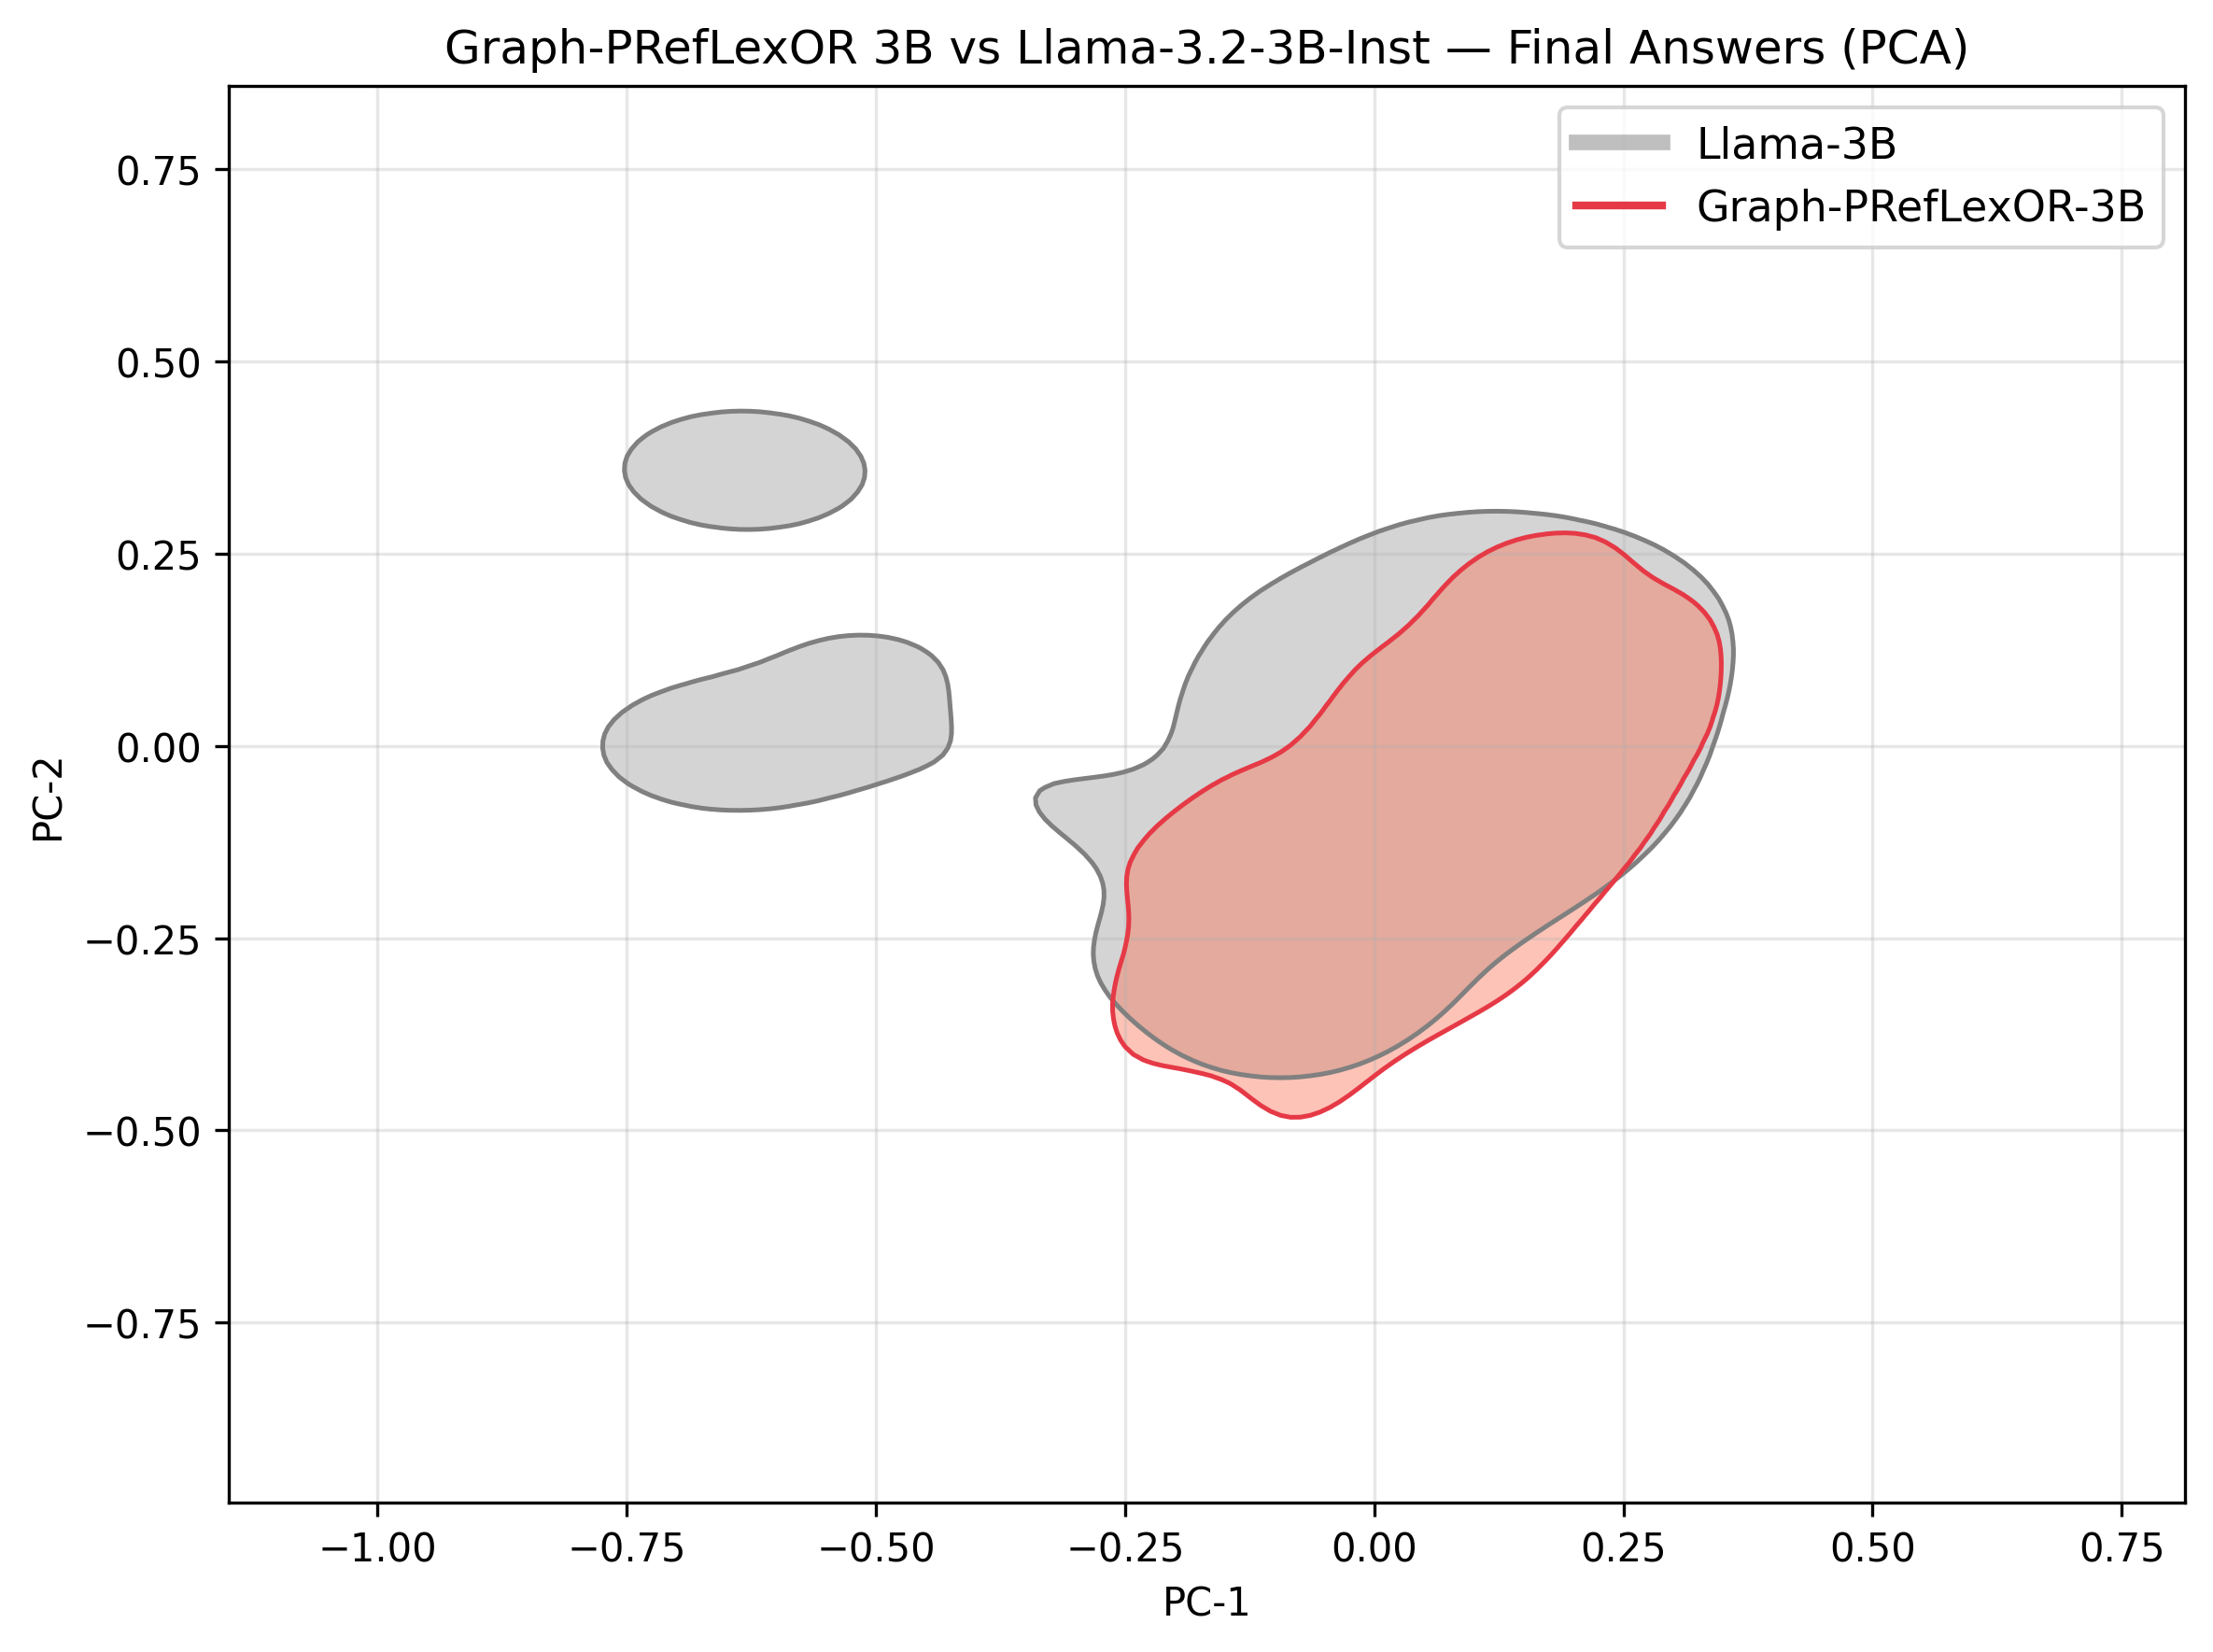

In [15]:
g_pca, l_pca = joint_pca(g3b_ans["emb"], l3b_ans["emb"])
plot_kde_single(g_pca, l_pca,
                "Graph-PRefLexOR 3B vs Llama-3.2-3B-Inst — Final Answers (PCA)",
                graph_name="Graph-PRefLexOR-3B", base_name="Llama-3B")

### Figure 5e — Final answers, 1.7B

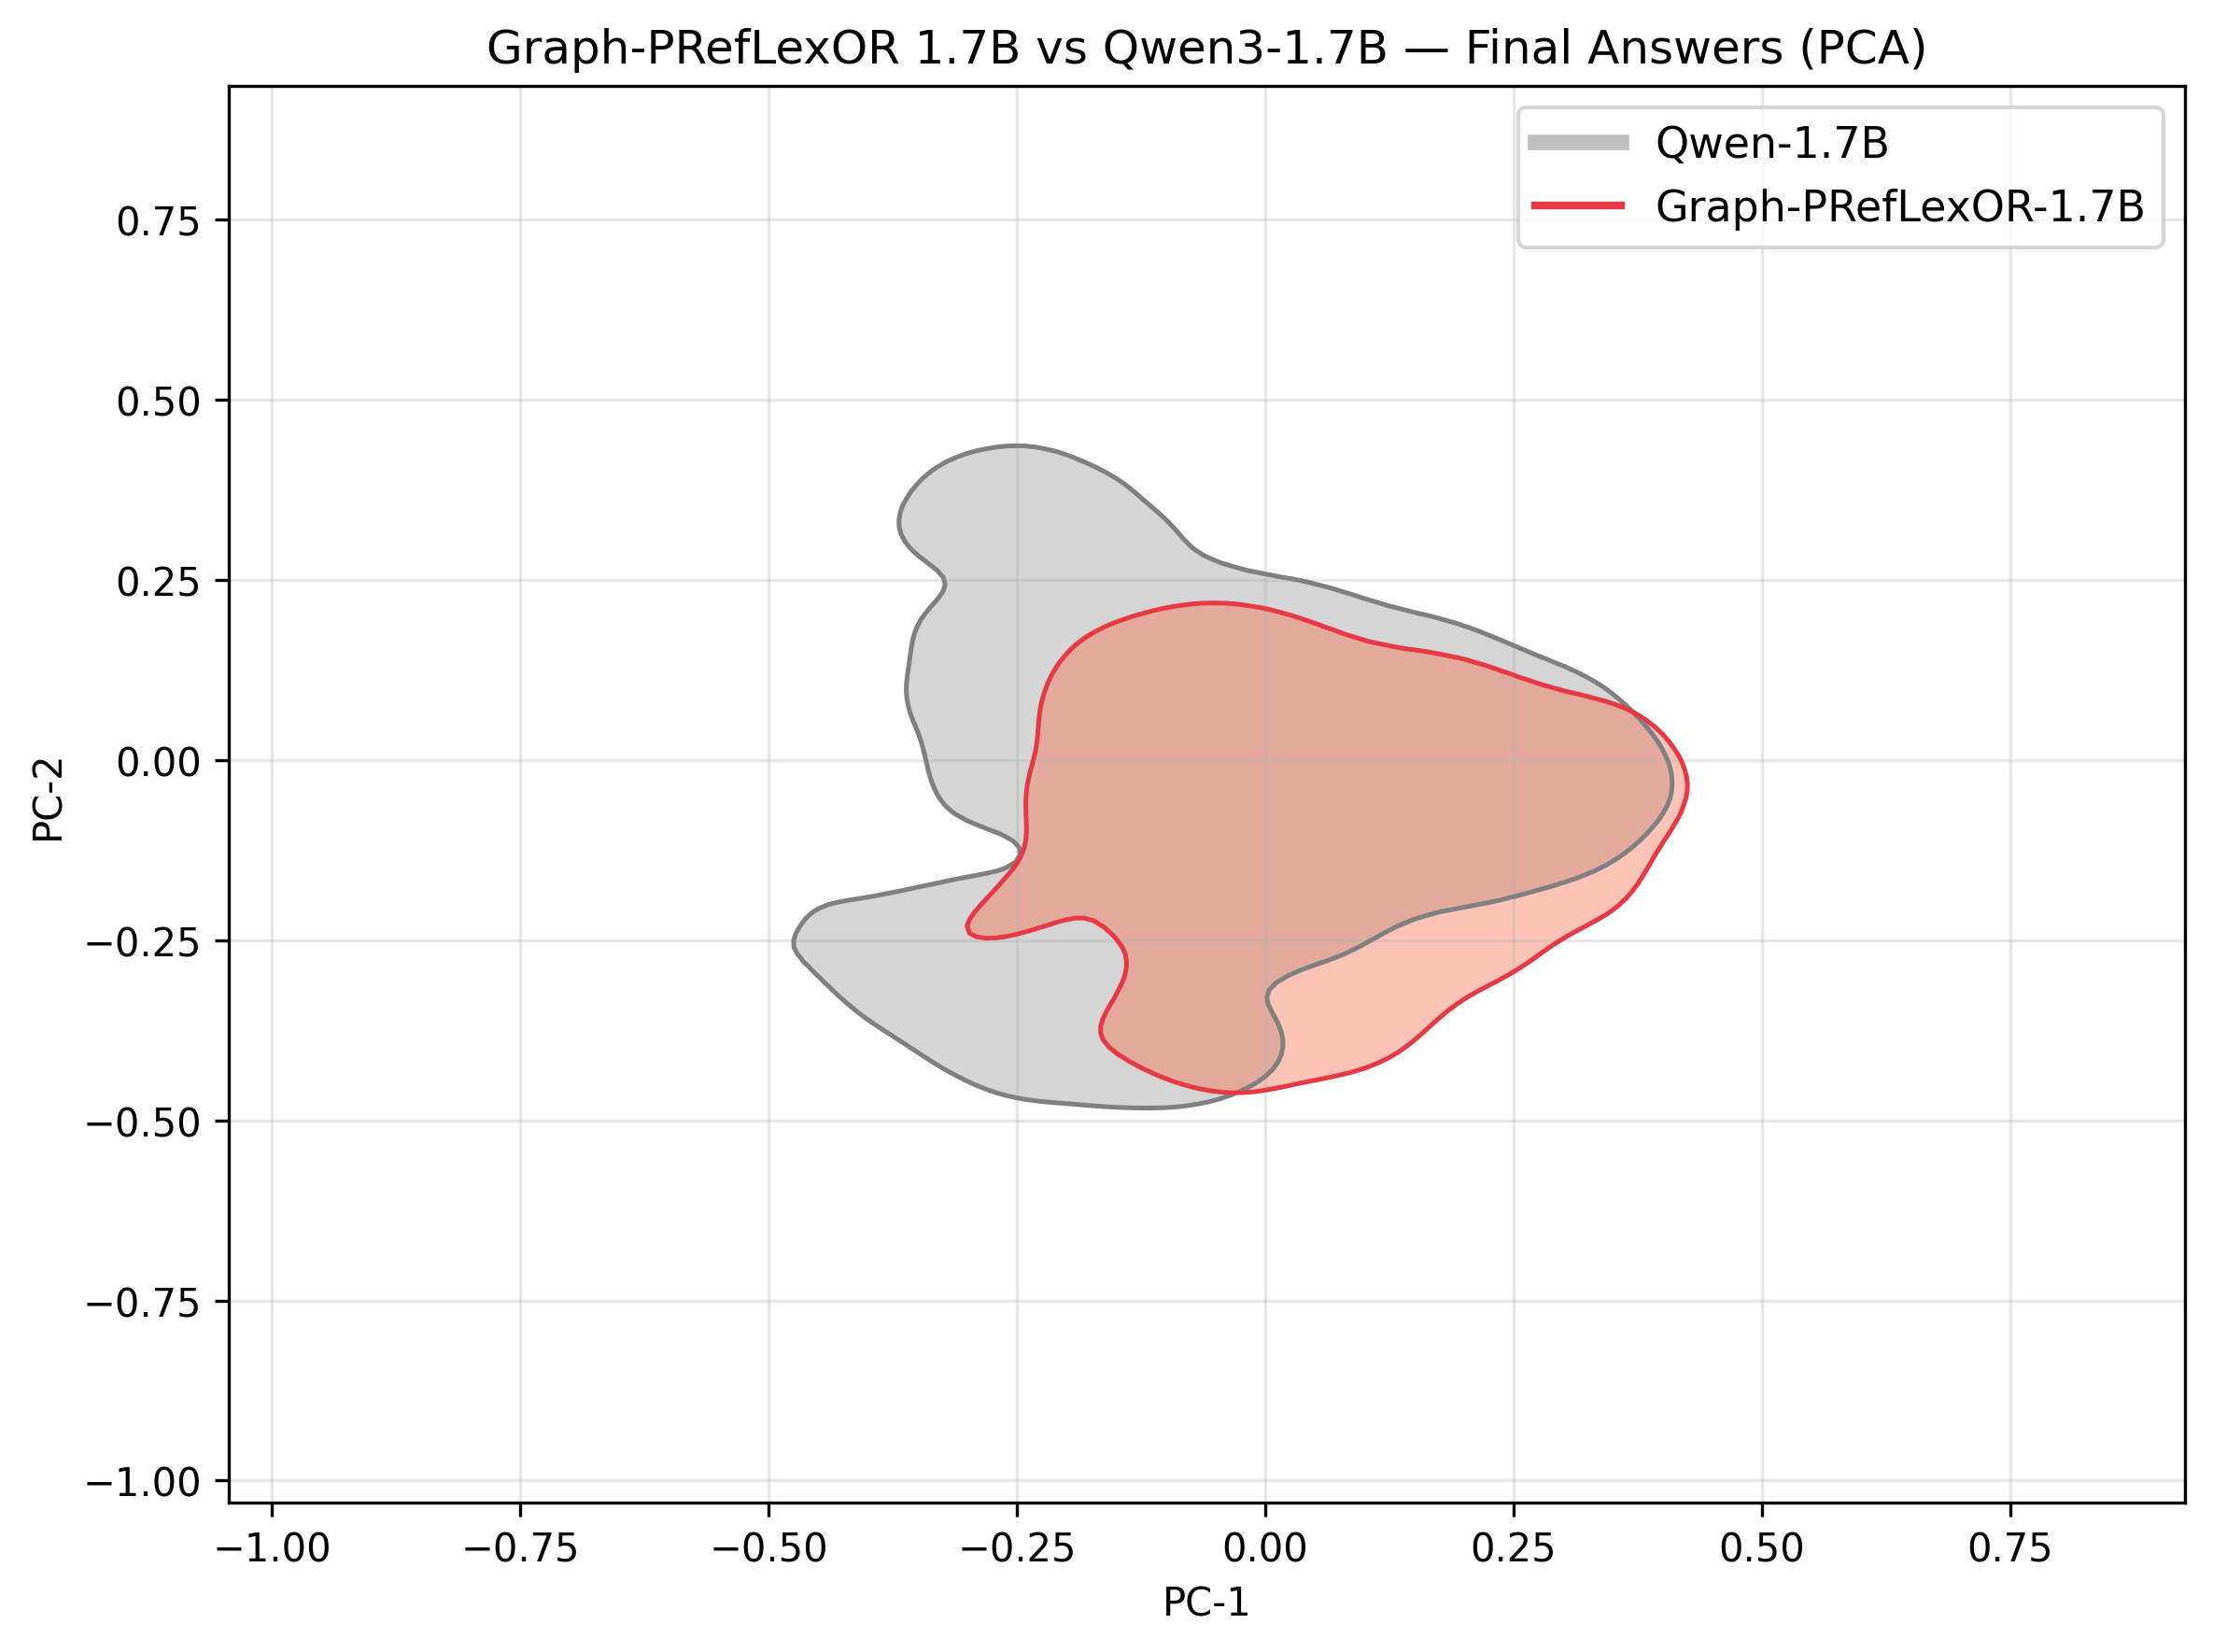

In [16]:
g_pca, q_pca = joint_pca(g1_7b_ans["emb"], q1_7b_ans["emb"])
plot_kde_single(g_pca, q_pca,
                "Graph-PRefLexOR 1.7B vs Qwen3-1.7B — Final Answers (PCA)",
                graph_name="Graph-PRefLexOR-1.7B", base_name="Qwen-1.7B")

## 5. Figure 6 — Directed trajectories

For each response, we compute one PCA centroid per phase (Graph-PRefLexOR) or one per 4 equal sequential chunks (baseline). Plotting all responses' polylines together reveals whether each model traverses semantic space *directionally* (Graph-PRefLexOR) or remains compact/entangled (baseline).

In [17]:
def per_response_phase_centroids(rec: Dict, pca: PCA, phases=PHASES) -> List[np.ndarray]:
    """Project `rec['emb']` with `pca`; return one (n_phases, 2) array per response."""
    proj = pca.transform(rec["emb"])
    trajs = []
    for rid in pd.unique(rec["ids"]):
        rmask = rec["ids"] == rid
        ctr = []
        for p in phases:
            pmask = rmask & np.array([l == p for l in rec["labels"]])
            ctr.append(proj[pmask].mean(axis=0) if pmask.any() else np.array([np.nan, np.nan]))
        trajs.append(np.array(ctr))
    return trajs

def per_response_chunk_centroids(rec: Dict, pca: PCA, n_chunks: int = 4) -> List[np.ndarray]:
    """Split each response's sentences into `n_chunks` sequential pieces; PCA-project chunk means."""
    proj = pca.transform(rec["emb"])
    trajs = []
    for rid in pd.unique(rec["ids"]):
        chunk_emb = np.array_split(proj[rec["ids"] == rid], n_chunks)
        trajs.append(np.array([c.mean(axis=0) for c in chunk_emb]))
    return trajs

def plot_trajectories(graph_trajs, base_trajs, title_a, title_b, labels_a, labels_b,
                      colors_a, color_b="#888888") -> None:
    """Side-by-side directed polylines: Graph-PRefLexOR (left), baseline (right)."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), dpi=200, sharey=True, sharex=True)
    for ax, trajs, title, labels, palette in [
        (ax1, graph_trajs, title_a, labels_a, colors_a),
        (ax2, base_trajs,  title_b, labels_b, [color_b]*len(labels_b)),
    ]:
        for traj in trajs:
            ax.plot(traj[:,0], traj[:,1], color="#c44", alpha=0.15, lw=0.6)
        for i, lab in enumerate(labels):
            pts = np.array([t[i] for t in trajs if not np.isnan(t[i]).any()])
            ax.scatter(pts[:,0], pts[:,1], c=palette[i], label=f"chunk {i+1}: {lab}",
                       s=18, edgecolors="white", linewidths=0.3, zorder=3)
        ax.set_title(title); ax.set_xlabel("PC-1"); ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    ax1.set_ylabel("PC-2")
    plt.tight_layout(); plt.show()

### Figure 6a — Reasoning trajectories (8B)

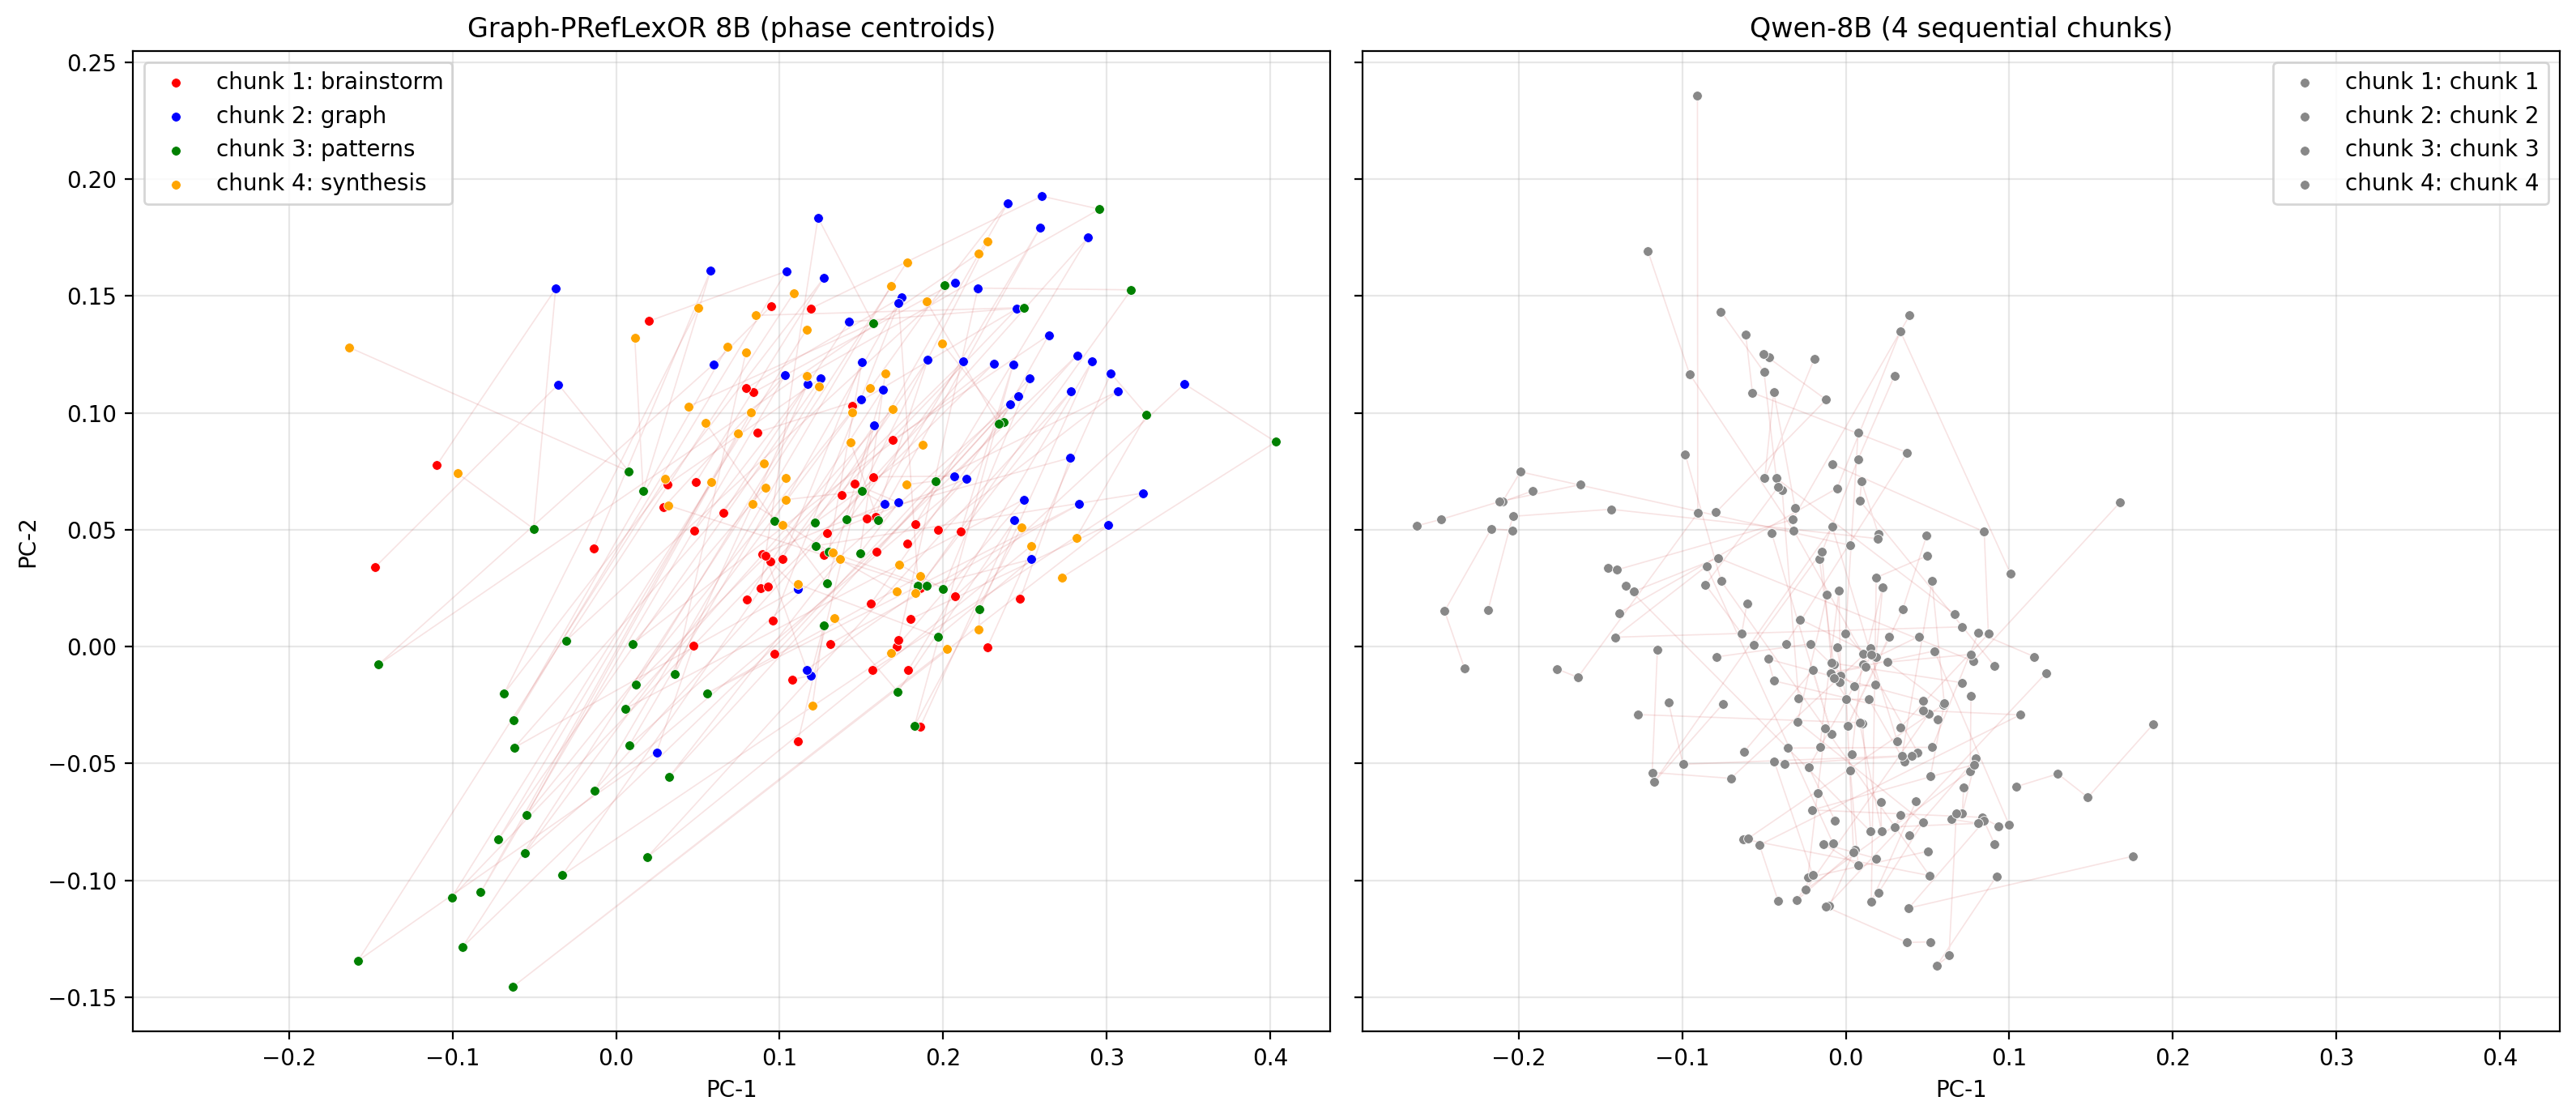

In [18]:
pca_res_8b = PCA(n_components=2).fit(np.vstack([g8b_res["emb"], q8b_res["emb"]]))
g_trajs = per_response_phase_centroids(g8b_res, pca_res_8b)
q_trajs = per_response_chunk_centroids(q8b_res, pca_res_8b)
plot_trajectories(
    g_trajs, q_trajs,
    "Graph-PRefLexOR 8B (phase centroids)",
    "Qwen-8B (4 sequential chunks)",
    labels_a=PHASES,
    labels_b=["chunk 1","chunk 2","chunk 3","chunk 4"],
    colors_a=[PHASE_COLORS[p] for p in PHASES],
)

### Figure 6b — Answer trajectories (8B)

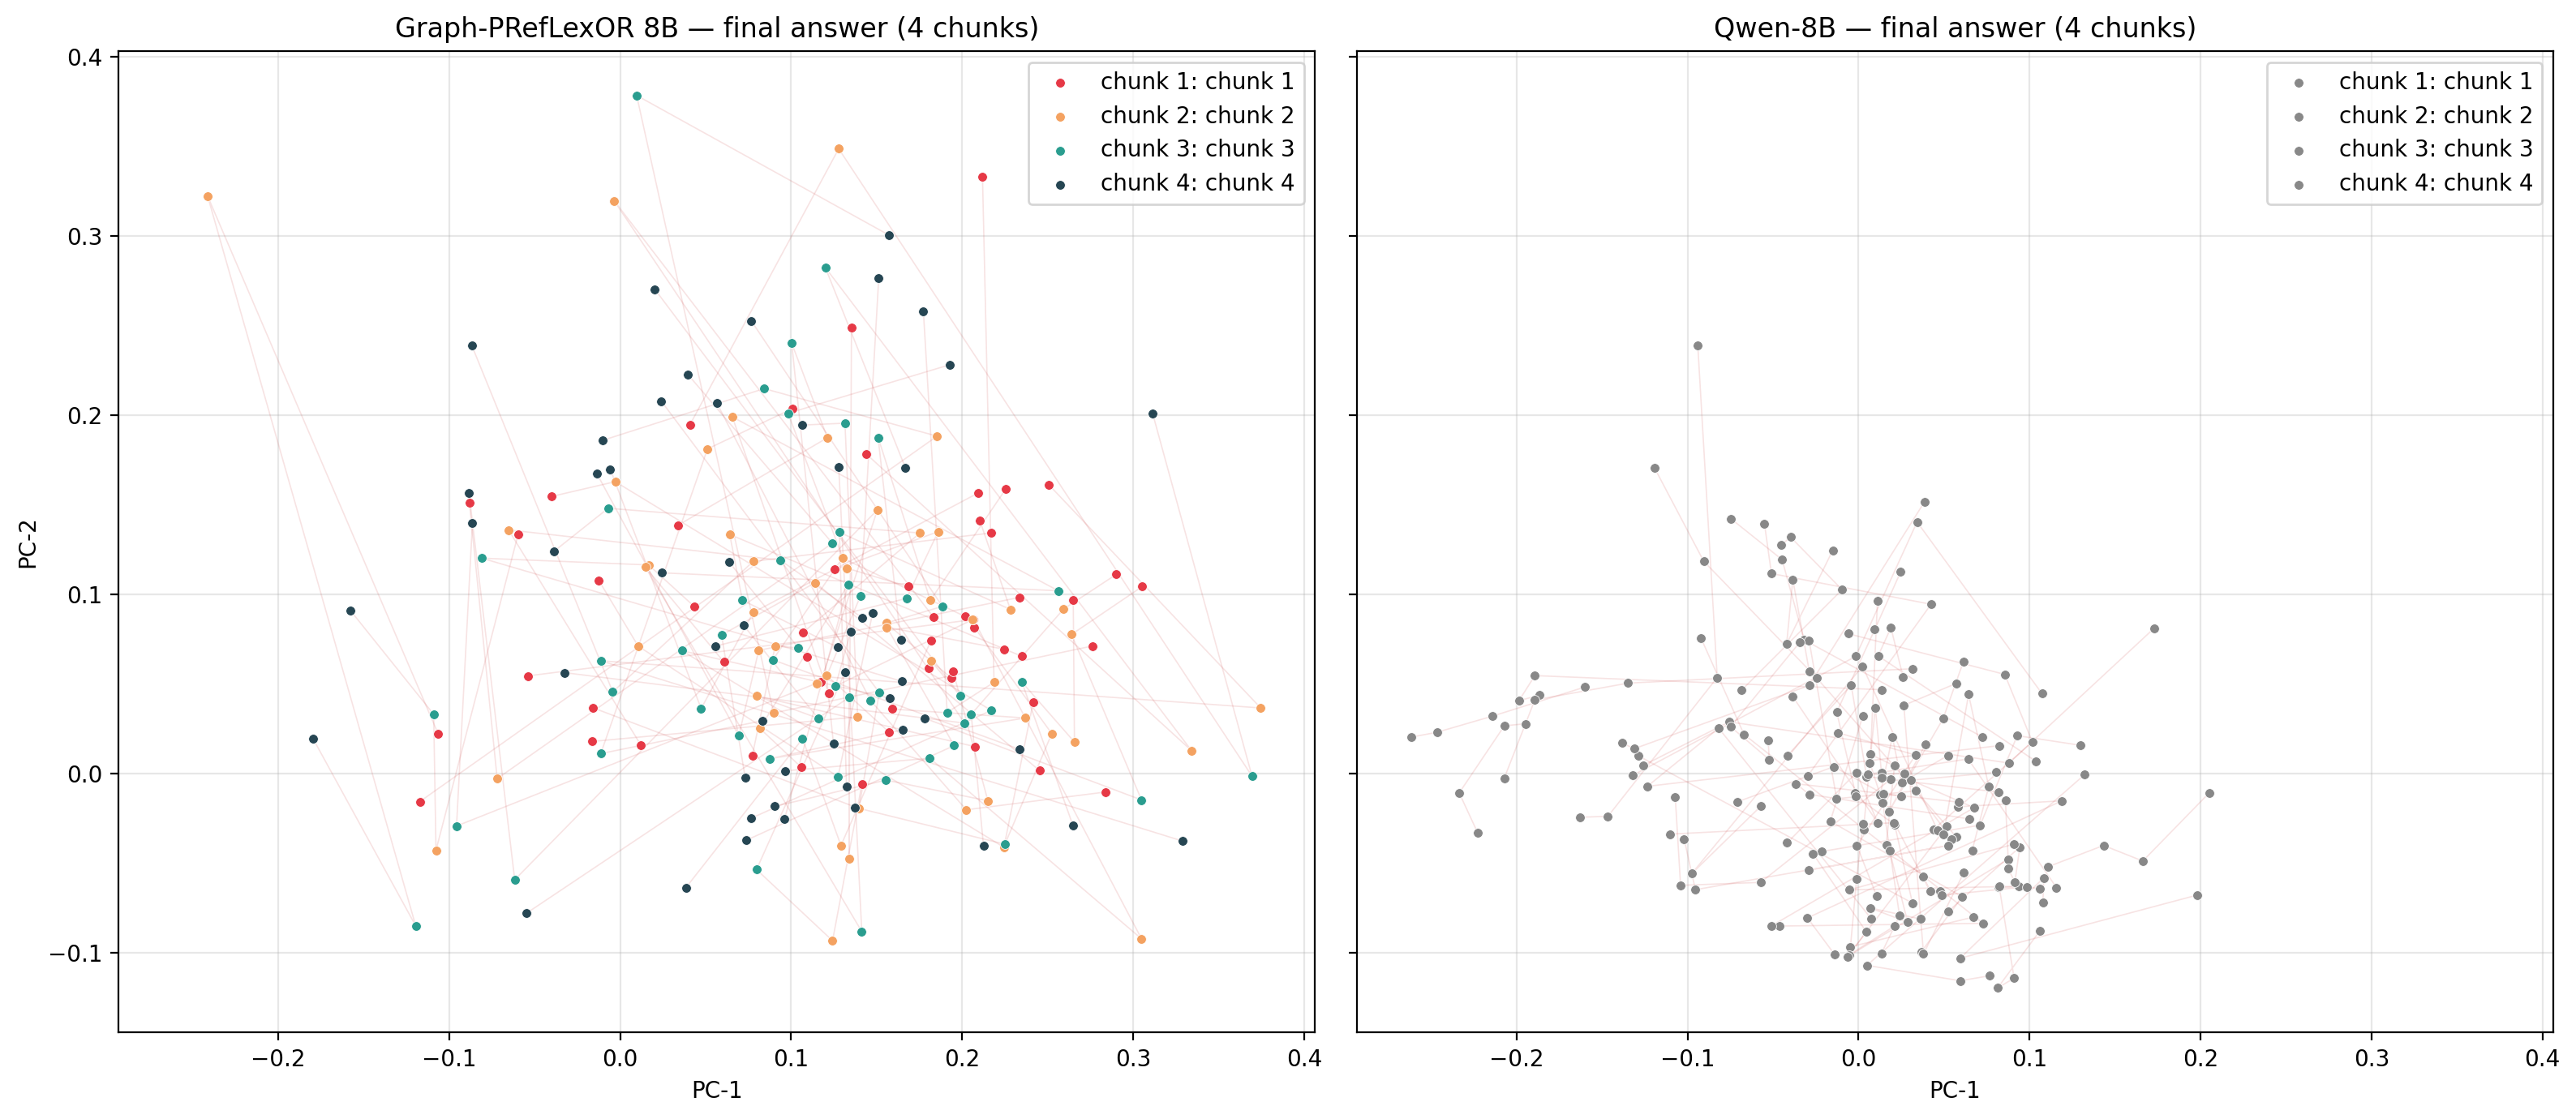

In [19]:
pca_ans_8b = PCA(n_components=2).fit(np.vstack([g8b_ans["emb"], q8b_ans["emb"]]))
g_trajs = per_response_chunk_centroids(g8b_ans, pca_ans_8b)
q_trajs = per_response_chunk_centroids(q8b_ans, pca_ans_8b)
plot_trajectories(
    g_trajs, q_trajs,
    "Graph-PRefLexOR 8B — final answer (4 chunks)",
    "Qwen-8B — final answer (4 chunks)",
    labels_a=[f"chunk {i+1}" for i in range(4)],
    labels_b=[f"chunk {i+1}" for i in range(4)],
    colors_a=["#E63946","#F4A261","#2A9D8F","#264653"],
)

## 6. Figure 7 + Table 1 — Quantifying semantic diversity

For each response we compute the **mean of all 6 pairwise cosine distances** between phase centroids (Graph-PRefLexOR) or chunk centroids (baseline, treated as pseudo-phases). Higher = more semantic differentiation between reasoning stages.

In [20]:
def per_response_centroid_distance(rec: Dict, group_by: str) -> np.ndarray:
    """Average pairwise cosine distance between per-response centroids.

    `group_by="phase"` → centroids are phase means (uses `rec['labels']`).
    `group_by="chunk"` → centroids are 4 equal sequential chunks of `rec['emb']`.
    """
    emb, ids = rec["emb"], rec["ids"]
    out = []
    for rid in pd.unique(ids):
        r_emb = emb[ids == rid]
        if group_by == "phase":
            r_labels = [rec["labels"][i] for i in np.where(ids == rid)[0]]
            centroids = []
            for p in PHASES:
                idx = [i for i, l in enumerate(r_labels) if l == p]
                centroids.append(r_emb[idx].mean(axis=0) if idx else None)
            valid = [c for c in centroids if c is not None]
            if len(valid) < 2: continue
            centroids = np.array(valid)
        elif group_by == "chunk":
            if len(r_emb) < 4: continue
            centroids = np.array([s.mean(axis=0) for s in np.array_split(r_emb, 4)])
        else:
            raise ValueError(group_by)
        out.append(pdist(centroids, metric="cosine").mean())
    return np.array(out)

def remove_outliers(x: np.ndarray, iqr_factor: float = 1.5) -> np.ndarray:
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return x[(x >= q1 - iqr_factor*iqr) & (x <= q3 + iqr_factor*iqr)]

def plot_diversity_violin(pairs: List[Tuple[str, np.ndarray, np.ndarray, str]], ylabel: str, title: str) -> None:
    """One violin pair per scale: (size_label, graph_data, base_data, base_name)."""
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    for i, (size, g_data, b_data, base_name) in enumerate(pairs):
        pos = [i*3 + 1, i*3 + 2]
        data = [remove_outliers(g_data), remove_outliers(b_data)]
        violin = ax.violinplot(data, positions=pos, showmedians=True, showextrema=True)
        for body, color in zip(violin["bodies"], ["#E63946", "#457B9D"]):
            body.set_facecolor(color); body.set_alpha(0.6)
        for p, d, c in zip(pos, data, ["#E63946", "#457B9D"]):
            ax.scatter(np.random.normal(p, 0.04, len(d)), d, color=c, alpha=0.4, s=18,
                       edgecolors="white", linewidths=0.3, zorder=3)
            ax.plot(p, np.mean(d), "D", color="black", markersize=6, zorder=4)
            ax.errorbar(p, np.mean(d), yerr=np.std(d), fmt="none", color="black",
                        capsize=5, elinewidth=1.5, zorder=4)
        ax.text((pos[0] + pos[1])/2, ax.get_ylim()[1] if False else 0,
                size, ha="center", va="top", transform=ax.get_xaxis_transform(),
                fontsize=12, fontweight="bold")
    ax.set_xticks([i*3 + 1.5 for i in range(len(pairs))])
    ax.set_xticklabels([s[0] for s in pairs])
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(handles=[Line2D([0],[0], color="#E63946", lw=4, alpha=0.6, label="Graph-PRefLexOR"),
               Line2D([0],[0], color="#457B9D", lw=4, alpha=0.6, label="Baseline")],
              loc="upper left", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.show()

### Figure 7a — Inter-phase diversity in reasoning traces

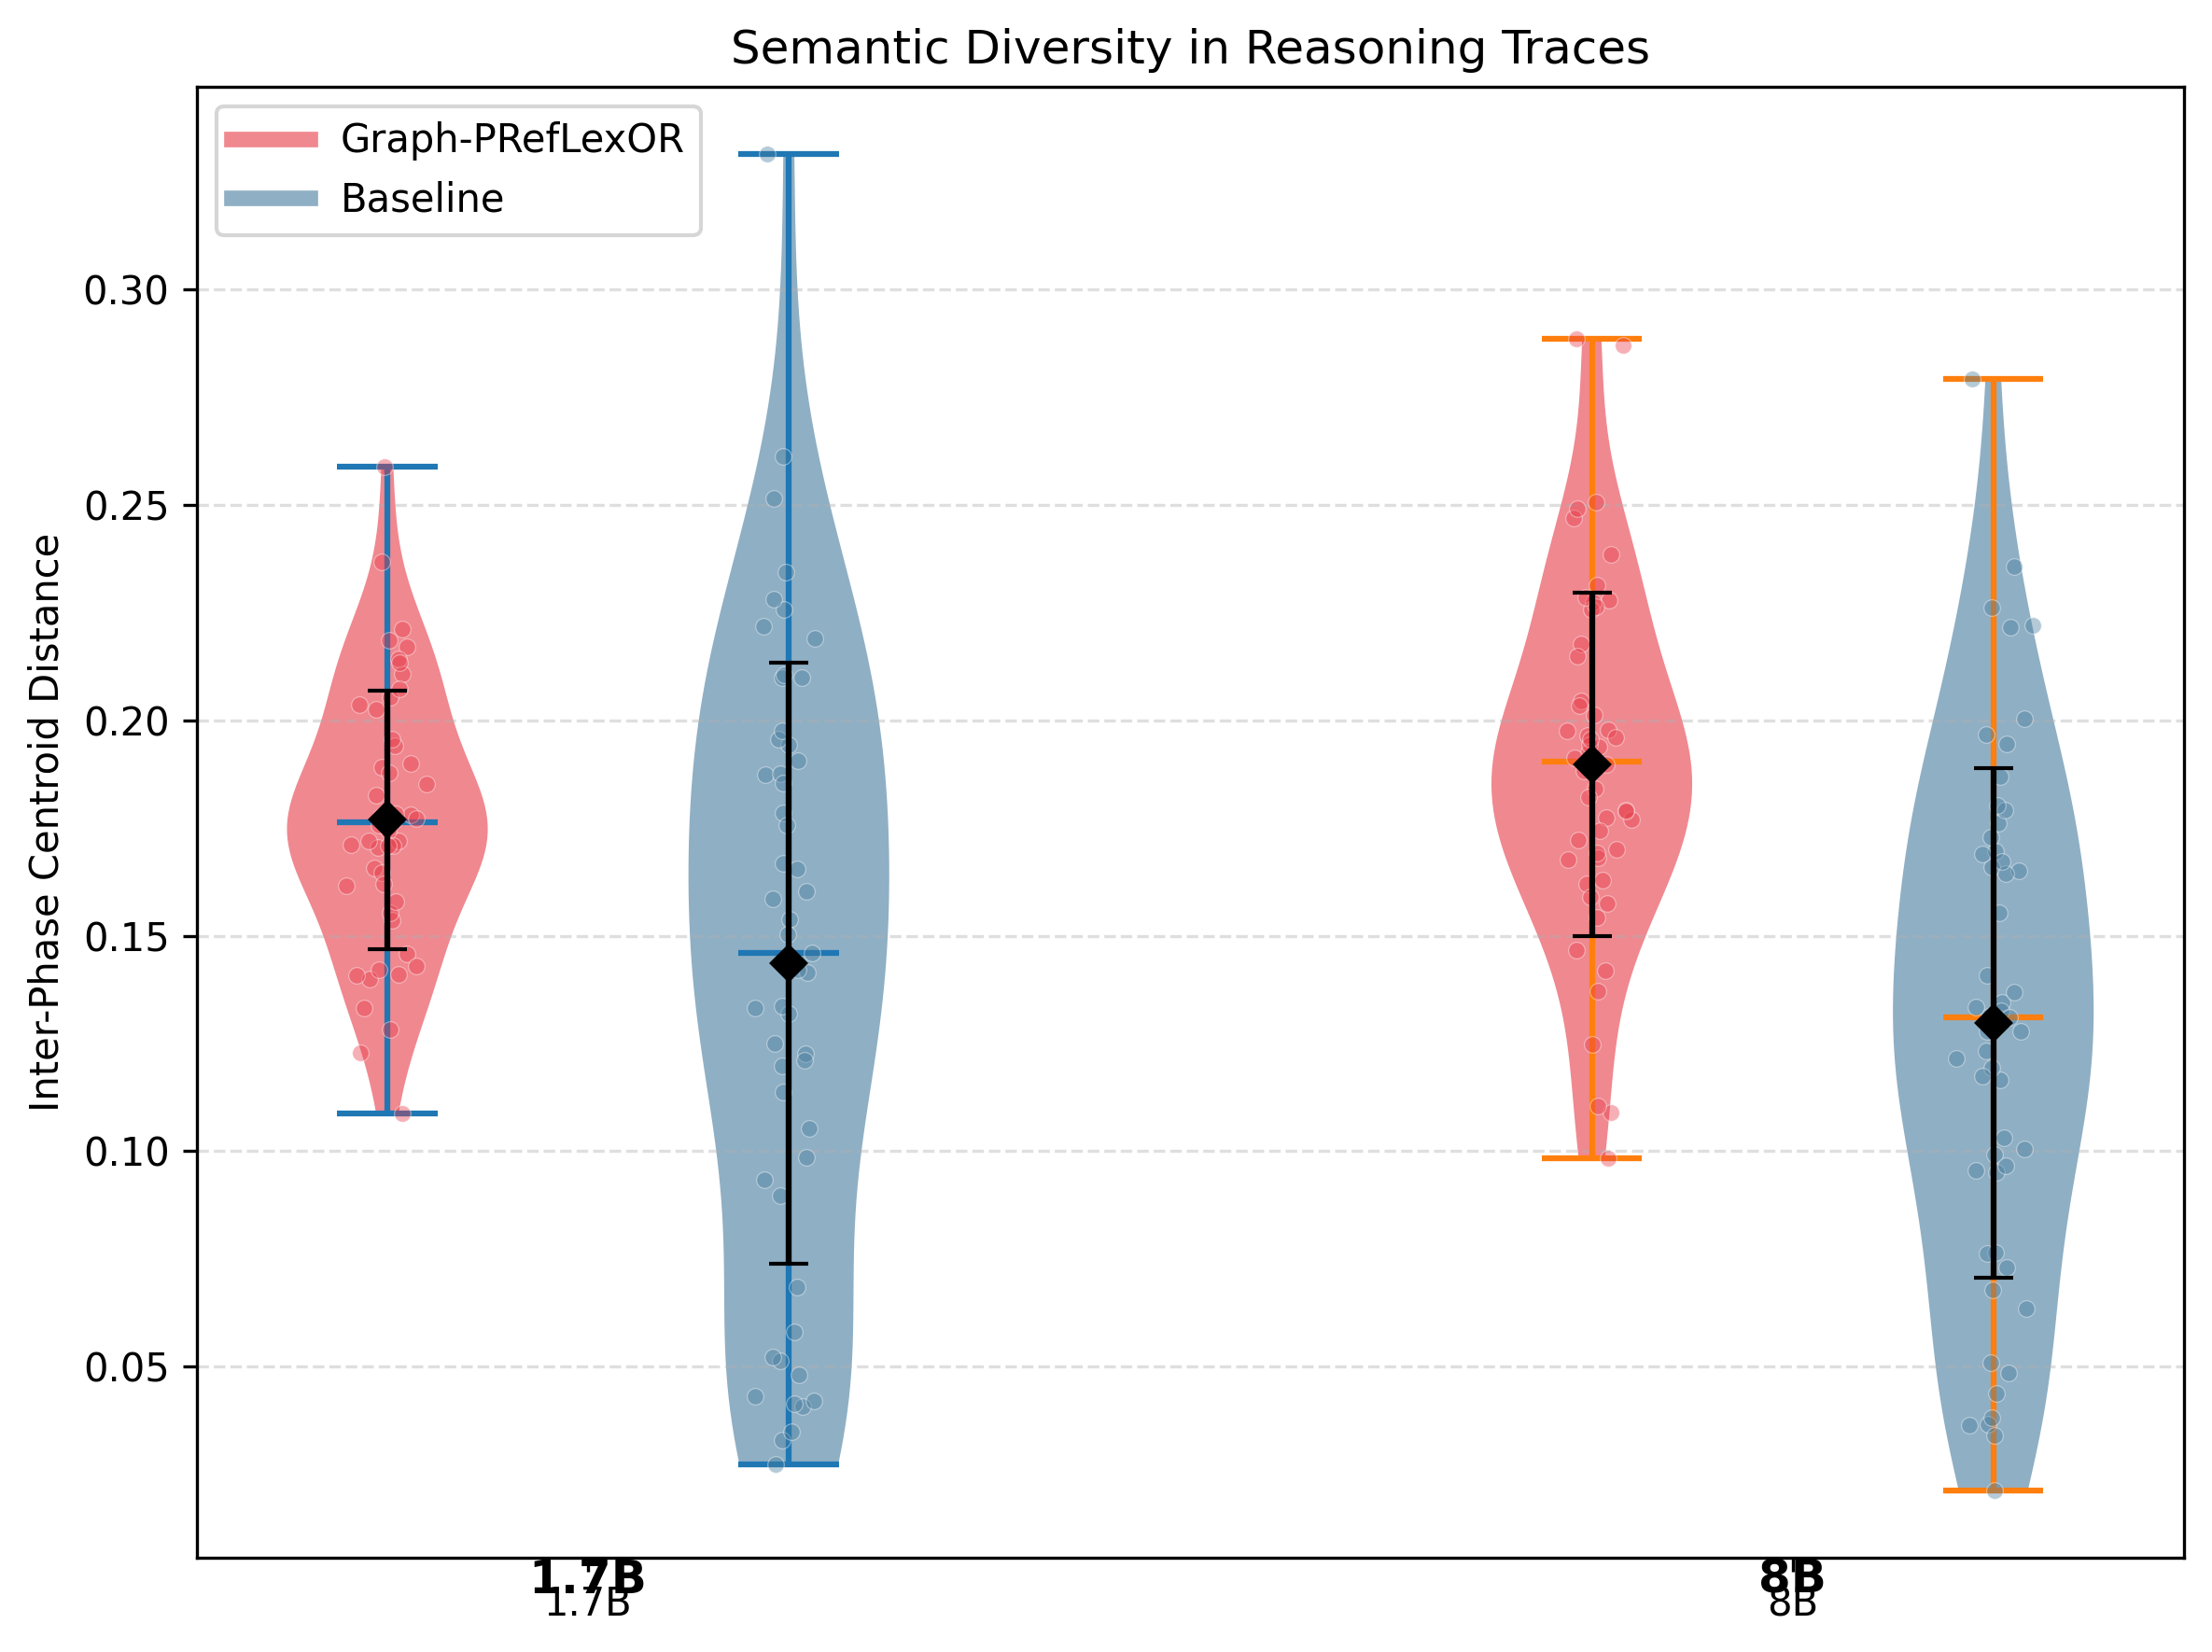

In [21]:
g8b_res_div   = per_response_centroid_distance(g8b_res,   group_by="phase")
q8b_res_div   = per_response_centroid_distance(q8b_res,   group_by="chunk")
g1_7b_res_div = per_response_centroid_distance(g1_7b_res, group_by="phase")
q1_7b_res_div = per_response_centroid_distance(q1_7b_res, group_by="chunk")

plot_diversity_violin(
    [("1.7B", g1_7b_res_div, q1_7b_res_div, "Qwen-1.7B"),
     ("8B",   g8b_res_div,   q8b_res_div,   "Qwen-8B")],
    ylabel="Inter-Phase Centroid Distance",
    title="Semantic Diversity in Reasoning Traces",
)

### Figure 7b — Inter-chunk diversity in final answers

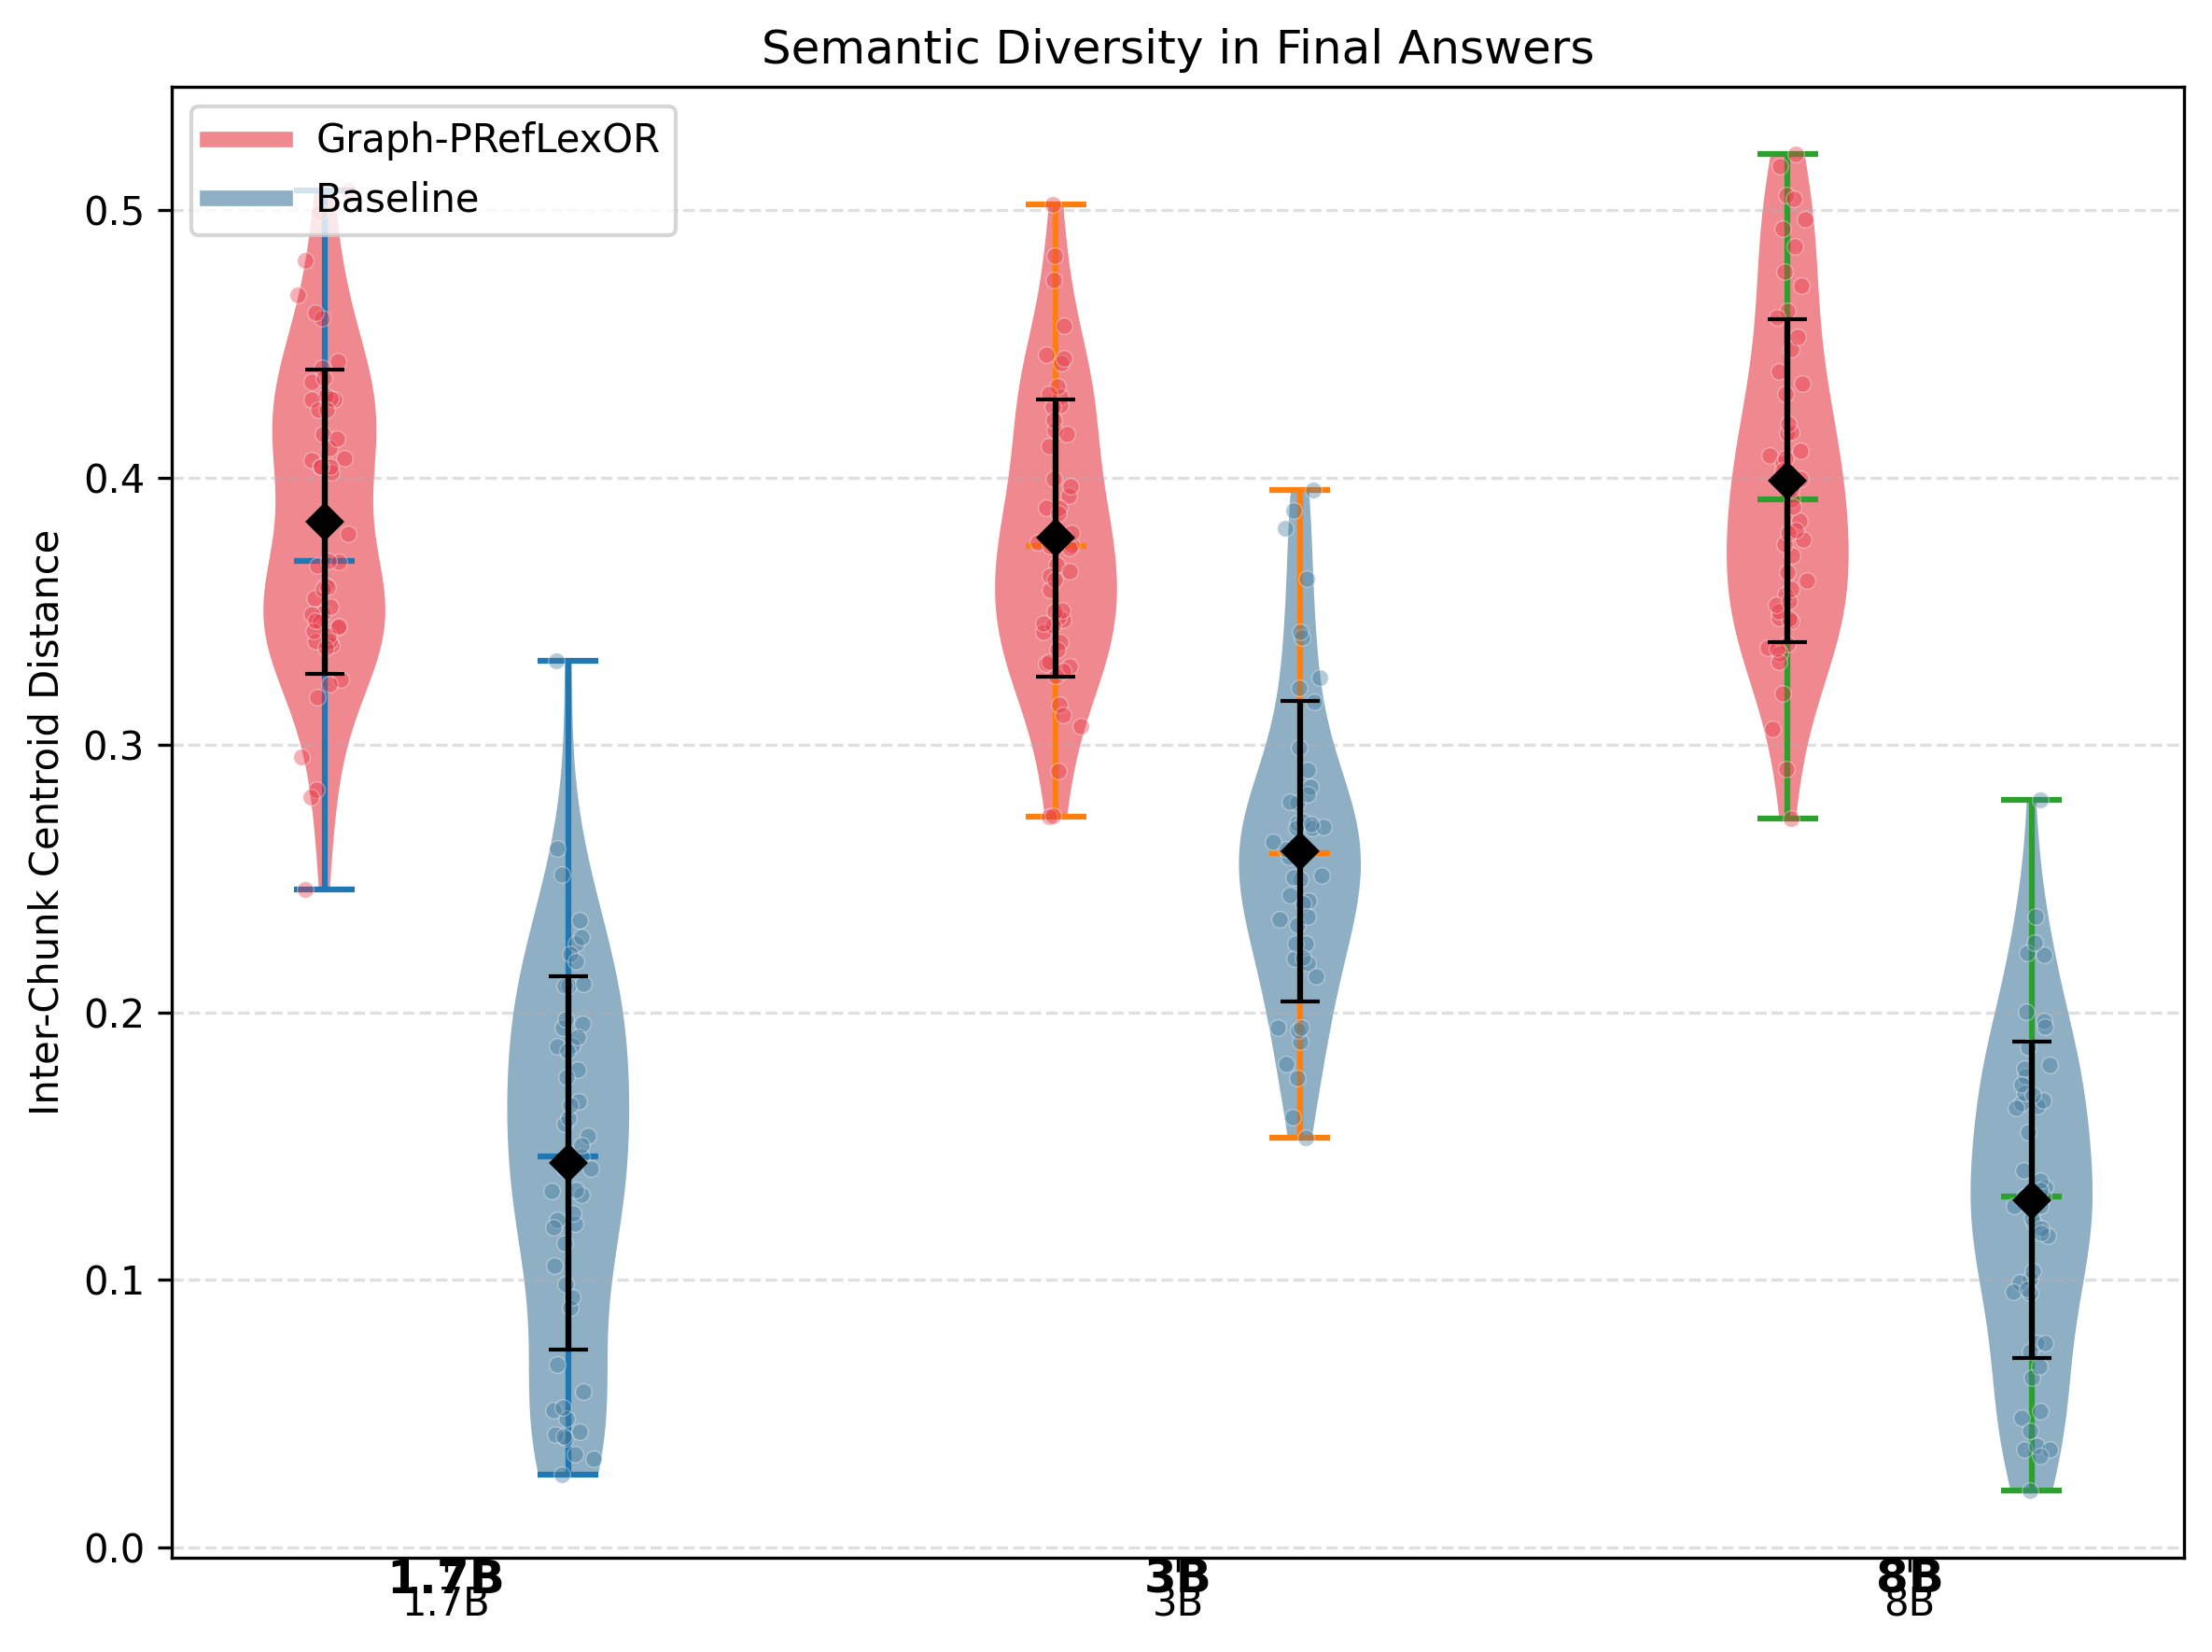

In [22]:
g8b_ans_div   = per_response_centroid_distance(g8b_ans,   group_by="chunk")
q8b_ans_div   = per_response_centroid_distance(q8b_ans,   group_by="chunk")
g3b_ans_div   = per_response_centroid_distance(g3b_ans,   group_by="chunk")
l3b_ans_div   = per_response_centroid_distance(l3b_ans,   group_by="chunk")
g1_7b_ans_div = per_response_centroid_distance(g1_7b_ans, group_by="chunk")
q1_7b_ans_div = per_response_centroid_distance(q1_7b_ans, group_by="chunk")

plot_diversity_violin(
    [("1.7B", g1_7b_ans_div, q1_7b_ans_div, "Qwen-1.7B"),
     ("3B",   g3b_ans_div,   l3b_ans_div,   "Llama-3B"),
     ("8B",   g8b_ans_div,   q8b_ans_div,   "Qwen-8B")],
    ylabel="Inter-Chunk Centroid Distance",
    title="Semantic Diversity in Final Answers",
)

### Table 1 — Mean diversity and gain over base models

In [23]:
rows = [
    ("Reasoning trace", "1.7B", g1_7b_res_div, q1_7b_res_div),
    ("Reasoning trace", "8B",   g8b_res_div,   q8b_res_div),
    ("Final answer",    "1.7B", g1_7b_ans_div, q1_7b_ans_div),
    ("Final answer",    "3B",   g3b_ans_div,   l3b_ans_div),
    ("Final answer",    "8B",   g8b_ans_div,   q8b_ans_div),
]
table = pd.DataFrame([{
    "Output Type":      out_type,
    "Model Scale":      scale,
    "Graph-PRefLexOR":  round(g.mean(), 2),
    "Base Model":       round(b.mean(), 2),
    "Absolute Increase": round(g.mean() - b.mean(), 2),
    "Gain":             f"{g.mean()/b.mean():.1f}×",
} for out_type, scale, g, b in rows])
print(table.to_string(index=False))

    Output Type Model Scale  Graph-PRefLexOR  Base Model  Absolute Increase Gain
Reasoning trace        1.7B             0.18        0.14               0.04 1.3×
Reasoning trace          8B             0.19        0.13               0.06 1.5×
   Final answer        1.7B             0.38        0.14               0.24 2.7×
   Final answer          3B             0.38        0.27               0.10 1.4×
   Final answer          8B             0.40        0.13               0.27 3.1×
